# Model Final

## Librerías

In [109]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset,TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt 
import random
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
import gc
import copy
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from typing import List, Optional, Tuple, Dict,Iterable
import re
from afg_puc import config
from afg_puc.common.utils import df_col_normalizer    
from typing import Optional, List 
from captum.attr import IntegratedGradients 
from statsmodels.tsa.statespace.sarimax import SARIMAX
device = torch.device("cuda")

## Import Data

In [43]:
df_consol=pd.read_parquet(config.PROCESSED_DATA_DIR / 'df_consol.parquet', engine='pyarrow')  

In [3]:
df_consol.index = pd.to_datetime(df_consol.index)
dow = df_consol.index.weekday  
df_consol["cercania_lunes"] = (0 - dow) % 7
df_consol["lejanania_lunes_pas"] = (dow - 0) % 7 
df_consol["mes"] = df_consol.index.month
df_consol["quincena"] = np.where(df_consol.index.day <= 15, 1, 2)
next_month = df_consol.index.to_series().shift(-1).dt.month
df_consol["cierre"] = (next_month != df_consol.index.month).astype(int)

In [4]:
df_consol = df_consol.sort_index()
test_days = 21
df_consol_train = df_consol.iloc[:-test_days]
df_consol_test = df_consol.iloc[-test_days:]

In [98]:
df_y_pred=df_consol[["plata","cobre","gas_natural","petroleo_brent","oro"]] 

## Arquitectura del LSTM

In [108]:
# ============================================================
# CONFIG
# ============================================================
MAX_EXOG: Optional[int] = None  # None = sin límite

COLLIN_CORR_TH = 0.90
USE_VIF_PRUNE  = True
VIF_TH         = 10.0

_EXOG_SELECTION_CACHE: Dict[tuple, List[str]] = {}


# ============================================================
# ---------------- UTILIDADES ----------------
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def _ensure_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if isinstance(df.index, pd.DatetimeIndex):
        return df
    if "FECHA" in df.columns:
        df["FECHA"] = pd.to_datetime(df["FECHA"])
        df = df.set_index("FECHA")
    return df


def _numeric_cols(df: pd.DataFrame) -> List[str]:
    return [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]


def _safe_df(df: pd.DataFrame) -> pd.DataFrame:
    return (df.replace([np.inf, -np.inf], np.nan).ffill().bfill())


def calculate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100


def _ljung_box_pval(residuals_1d, lag):
    r = np.asarray(residuals_1d).astype(float).ravel()
    n = len(r)
    if lag < 1 or n <= lag:
        return np.nan
    try:
        df_lb = acorr_ljungbox(r, lags=[lag], return_df=True)
        return float(df_lb["lb_pvalue"].iloc[0])
    except Exception:
        return np.nan


def _z_value(alpha: float) -> float:
    if abs(alpha - 0.05) < 1e-12:
        return 1.96
    try:
        from scipy.stats import norm
        return float(norm.ppf(1.0 - alpha / 2.0))
    except Exception:
        return 1.96


def _safe_varname_from_asset(asset_name: str) -> str:
    s = str(asset_name).strip().lower()
    s = re.sub(r"\W+", "_", s)
    if re.match(r"^\d", s):
        s = "_" + s
    return f"df_{s}_features"


# ============================================================
# --------- SELECCIÓN EXÓGENAS  ----------
#   (1) ranking por |corr(feature, target)| en TRAIN
#   (2) poda colinealidad entre features
#   (3) poda por VIF
#   (4) cap MAX_EXOG
# ============================================================
def _prune_collinearity_by_corr_ranked(df_train: pd.DataFrame, ranked_cols: List[str], corr_th: float) -> List[str]:
    if len(ranked_cols) <= 1:
        return ranked_cols
    X = _safe_df(df_train[ranked_cols]).dropna()
    if len(X) < 5:
        return ranked_cols
    C = X.corr().abs()
    kept = []
    for c in ranked_cols:
        if not kept:
            kept.append(c)
            continue
        if (C.loc[c, kept].max() if kept else 0.0) < corr_th:
            kept.append(c)
    return kept


def _prune_by_vif(df_train: pd.DataFrame, cols: List[str], vif_th: float) -> List[str]:
    cols = cols[:]
    if len(cols) <= 2:
        return cols

    X = _safe_df(df_train[cols]).dropna()
    if len(X) < 25:
        return cols

    Xs = (X - X.mean()) / (X.std(ddof=0) + 1e-12)
    Xs = Xs.values

    while Xs.shape[1] > 2:
        vifs = []
        for i in range(Xs.shape[1]):
            try:
                vifs.append(float(variance_inflation_factor(Xs, i)))
            except Exception:
                vifs.append(np.inf)

        max_vif = float(np.max(vifs))
        if np.isfinite(max_vif) and max_vif <= vif_th:
            break

        j = int(np.argmax(vifs))
        cols.pop(j)
        Xs = np.delete(Xs, j, axis=1)

    return cols


def _select_exog_cols(df_train: pd.DataFrame, target_col: str, max_exog: Optional[int]) -> List[str]:
    """
    Selección exógenas SOLO con TRAIN (sin leakage), SIN Granger:
      (1) Ranking por |corr(feature, target)|
      (2) Poda colinealidad por corr entre features
      (3) Poda por VIF
      (4) Cap opcional si max_exog != None
    """
    num_cols = _numeric_cols(df_train)
    candidates = [c for c in num_cols if c != target_col]
    if not candidates:
        return []

    candidates = [c for c in candidates if df_train[c].nunique(dropna=True) > 1]
    if not candidates:
        return []

    idx0 = df_train.index[0] if len(df_train.index) else None
    idx1 = df_train.index[-1] if len(df_train.index) else None
    key = (
        target_col, idx0, idx1, len(df_train),
        tuple(candidates),
        max_exog,
        COLLIN_CORR_TH, USE_VIF_PRUNE, VIF_TH
    )
    if key in _EXOG_SELECTION_CACHE:
        return _EXOG_SELECTION_CACHE[key][:]

    tmp = _safe_df(df_train[[target_col] + candidates]).dropna()
    if len(tmp) < 10:
        ranked = candidates[:]
        corr_abs = pd.Series({c: 0.0 for c in ranked})
    else:
        corr_abs = tmp[candidates].corrwith(tmp[target_col]).abs()
        corr_abs = corr_abs.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        ranked = corr_abs.sort_values(ascending=False).index.tolist()

    if max_exog is not None:
        ranked_pool = ranked[:max_exog * 3] if (max_exog * 3) < len(ranked) else ranked[:]
    else:
        ranked_pool = ranked[:]

    selected = _prune_collinearity_by_corr_ranked(df_train, ranked_pool, COLLIN_CORR_TH)

    if USE_VIF_PRUNE and len(selected) > 2:
        selected = _prune_by_vif(df_train, selected, VIF_TH)

    if (max_exog is not None) and (len(selected) > max_exog):
        selected = sorted(selected, key=lambda c: float(corr_abs.get(c, 0.0)), reverse=True)[:max_exog]

    _EXOG_SELECTION_CACHE[key] = selected[:]
    return selected


# ============================================================
# ---------------- SECUENCIAS ----------------
# ============================================================
def create_sequences_multi(X, y, timesteps: int, horizon: int):
    X_seq, y_seq = [], []
    n = len(X)
    last_start = n - timesteps - horizon
    for i in range(last_start + 1):
        X_seq.append(X[i:i+timesteps])
        y_block = y[i+timesteps:i+timesteps+horizon].reshape(-1)
        y_seq.append(y_block)
    return np.array(X_seq), np.array(y_seq)


# ============================================================
# ---------------- MODELO ----------------
# ============================================================
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_size=128, num_layers=2, dropout=0.2, bidirectional=False, output_dim=7):
        super().__init__()
        self.lstm = nn.LSTM(
            input_dim, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        lstm_output_size = hidden_size * 2 if bidirectional else hidden_size
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_output_size, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = lstm_out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out


# ============================================================
# GRID SEARCH (CV rolling) - MULTI-HORIZON DIRECTO
# ============================================================
def train_grid_for_asset(asset_name, param_grid, df_train_full, lb_horizon=7):
    criterion = nn.MSELoss()
    results = []

    target_col = asset_name
    df_train_full = _ensure_datetime_index(df_train_full)
    tscv = TimeSeriesSplit(n_splits=5)

    print(f"\n[GRID SEARCH] Iniciando para: {asset_name}")

    for i, cfg in enumerate(param_grid):
        print(f"Config {i}: {cfg}")

        timesteps  = int(cfg["timesteps"])
        batch_size = int(cfg["batch_size"])
        horizon    = int(lb_horizon) if lb_horizon is not None else 7

        fold_metrics = {
            "rmse_h": [], "mape_h": [],
            "train_loss": [], "val_loss": [],
            "gap": [],
            "lb_pval": [], "lb_lag_used": [],
            "n_exog": []
        }

        for fold, (train_idx, val_idx) in enumerate(tscv.split(df_train_full)):
            df_t = df_train_full.iloc[train_idx].copy()
            df_v = df_train_full.iloc[val_idx].copy()

            exog_cols = _select_exog_cols(df_t, target_col, MAX_EXOG)
            fold_metrics["n_exog"].append(len(exog_cols))

            feature_cols = [target_col] + exog_cols

            X_t = df_t[feature_cols].values.astype(np.float32)
            y_t = df_t[[target_col]].values.astype(np.float32)

            X_v = df_v[feature_cols].values.astype(np.float32)
            y_v = df_v[[target_col]].values.astype(np.float32)

            if len(X_t) < (timesteps + horizon + 2):
                continue

            scaler_x = StandardScaler().fit(X_t)
            scaler_y = StandardScaler().fit(y_t)

            X_t_sc = scaler_x.transform(X_t)
            y_t_sc = scaler_y.transform(y_t)

            # concateno últimos timesteps del train con val para secuencias continuas
            X_v_full = np.vstack([X_t[-timesteps:].copy(), X_v])
            y_v_full = np.vstack([y_t[-timesteps:].copy(), y_v])

            X_v_sc = scaler_x.transform(X_v_full)
            y_v_sc = scaler_y.transform(y_v_full)

            X_train_seq, y_train_seq = create_sequences_multi(X_t_sc, y_t_sc, timesteps, horizon)
            X_val_seq,   y_val_seq   = create_sequences_multi(X_v_sc, y_v_sc, timesteps, horizon)

            if len(X_train_seq) == 0 or len(X_val_seq) == 0:
                continue

            train_ds = TensorDataset(
                torch.tensor(X_train_seq, dtype=torch.float32, device=device),
                torch.tensor(y_train_seq, dtype=torch.float32, device=device)
            )
            train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

            model = LSTMRegressor(
                input_dim=X_train_seq.shape[2],
                hidden_size=int(cfg["hidden_size"]),
                num_layers=2,
                dropout=float(cfg["dropout"]),
                bidirectional=bool(cfg["bidirectional"]),
                output_dim=horizon
            ).to(device)

            optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=float(cfg["lr"]),
                weight_decay=float(cfg["weight_decay"])
            )

            epochs_cv = 100
            patience  = 10
            min_delta = 1e-4

            best_val = float("inf")
            best_state = None
            patience_counter = 0

            X_val_tensor = torch.tensor(X_val_seq, dtype=torch.float32, device=device)
            y_val_tensor = torch.tensor(y_val_seq, dtype=torch.float32, device=device)

            for epoch in range(epochs_cv):
                model.train()
                epoch_loss = 0.0
                batches = 0
                for Xb, yb in train_loader:
                    optimizer.zero_grad()
                    pred = model(Xb)
                    loss = criterion(pred, yb)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    epoch_loss += float(loss.item())
                    batches += 1

                model.eval()
                with torch.no_grad():
                    pred_val = model(X_val_tensor)
                    val_loss = float(criterion(pred_val, y_val_tensor).item())

                if val_loss < (best_val - min_delta):
                    best_val = val_loss
                    best_state = copy.deepcopy(model.state_dict())
                    patience_counter = 0
                else:
                    patience_counter += 1

                if patience_counter >= patience:
                    break

            if best_state is not None:
                model.load_state_dict(best_state)

            model.eval()
            with torch.no_grad():
                pred_val = model(X_val_tensor)
                val_loss_item = float(criterion(pred_val, y_val_tensor).item())

                pred_train = model(torch.tensor(X_train_seq, dtype=torch.float32, device=device))
                train_loss_item = float(
                    criterion(pred_train, torch.tensor(y_train_seq, dtype=torch.float32, device=device)).item()
                )

                pred_h_sc = pred_val[0].detach().cpu().numpy().reshape(-1, 1)
                true_h_sc = y_val_seq[0].reshape(-1, 1)

                pred_h = scaler_y.inverse_transform(pred_h_sc).reshape(-1)
                true_h = scaler_y.inverse_transform(true_h_sc).reshape(-1)

                rmse_h = float(np.sqrt(np.mean((pred_h - true_h) ** 2)))
                mape_h = float(calculate_mape(true_h, pred_h))

            gap = val_loss_item - train_loss_item
            residuals = (true_h - pred_h)
            lag_used = int(min(max(1, len(residuals) - 1), 10))
            p_lb = float(_ljung_box_pval(residuals, lag_used))

            fold_metrics["rmse_h"].append(rmse_h)
            fold_metrics["mape_h"].append(mape_h)
            fold_metrics["train_loss"].append(train_loss_item)
            fold_metrics["val_loss"].append(val_loss_item)
            fold_metrics["gap"].append(gap)
            fold_metrics["lb_lag_used"].append(lag_used)
            fold_metrics["lb_pval"].append(p_lb)

            del model, optimizer, train_ds, train_loader, X_val_tensor, y_val_tensor
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            gc.collect()

        avg_val_loss = np.mean(fold_metrics["val_loss"]) if fold_metrics["val_loss"] else np.nan
        avg_gap      = np.mean(fold_metrics["gap"])      if fold_metrics["gap"] else np.nan

        gap_penalty = max(0.0, avg_gap - 1.0) * 0.5
        combined_score = avg_val_loss + gap_penalty

        results.append({
            "cfg_id": i,
            "combined_score": combined_score,
            "gap_penalty": gap_penalty,
            "val_loss": avg_val_loss,
            "gap": avg_gap,
            "gap_std": np.std(fold_metrics["gap"]) if fold_metrics["gap"] else np.nan,
            "rmse_cv_h": np.mean(fold_metrics["rmse_h"]) if fold_metrics["rmse_h"] else np.nan,
            "val_mape_h": np.mean(fold_metrics["mape_h"]) if fold_metrics["mape_h"] else np.nan,
            "train_loss": np.mean(fold_metrics["train_loss"]) if fold_metrics["train_loss"] else np.nan,
            "ljung_box_pval_mean": np.nanmean(fold_metrics["lb_pval"]) if fold_metrics["lb_pval"] else np.nan,
            "ljung_box_lag_used_mean": np.nanmean(fold_metrics["lb_lag_used"]) if fold_metrics["lb_lag_used"] else np.nan,
            "n_exog_used_mean": np.mean(fold_metrics["n_exog"]) if fold_metrics["n_exog"] else np.nan,
            "n_exog_used_std":  np.std(fold_metrics["n_exog"])  if fold_metrics["n_exog"] else np.nan,
            **cfg
        })

    df_results = pd.DataFrame(results).sort_values("combined_score").reset_index(drop=True)
    cols_order = [
        "cfg_id", "combined_score", "gap_penalty",
        "val_loss", "gap", "gap_std",
        "rmse_cv_h", "val_mape_h",
        "ljung_box_pval_mean", "ljung_box_lag_used_mean",
        "train_loss",
        "hidden_size", "lr", "dropout", "timesteps", "batch_size", "weight_decay", "bidirectional",
        "n_exog_used_mean", "n_exog_used_std"
    ]
    final_cols = [c for c in cols_order if c in df_results.columns] + [c for c in df_results.columns if c not in cols_order]
    return df_results[final_cols]


# ============================================================
# FEATURES DF 
# ============================================================
def _build_features_report(df_train: pd.DataFrame, target_col: str, exog_cols: list) -> pd.DataFrame:
    df_train = _ensure_datetime_index(df_train)
    rows = []

    rows.append({
        "feature": target_col,
        "role": "target_as_feature",
        "abs_corr_with_target": 1.0,
        "notes": "Target incluido como feature autoregresivo en X=[target]+exógenas."
    })

    if exog_cols:
        tmp = _safe_df(df_train[[target_col] + exog_cols]).dropna()
        if len(tmp) >= 10:
            corr = tmp[exog_cols].corrwith(tmp[target_col]).abs()
        else:
            corr = pd.Series({c: np.nan for c in exog_cols})

        for x in exog_cols:
            rows.append({
                "feature": x,
                "role": "exog_selected",
                "abs_corr_with_target": float(corr.get(x, np.nan)),
                "notes": "Seleccionada por ranking |corr| + poda colinealidad (corr) + poda VIF."
            })

    df_feat = pd.DataFrame(rows)
    df_feat_ex = df_feat[df_feat["role"] != "target_as_feature"].sort_values("abs_corr_with_target", ascending=False)
    df_feat_t  = df_feat[df_feat["role"] == "target_as_feature"]
    return pd.concat([df_feat_t, df_feat_ex], ignore_index=True)


# ============================================================
# ----------- CAPTUM: IG estable para LSTM + cuDNN ------------
# ============================================================
def _safe_varname_from_asset_captum(asset_name: str) -> str:
    return _safe_varname_from_asset(asset_name).replace("_features", "_captum")


def _captum_ig_feature_importance_multihorizon(
    model: nn.Module,
    X_seq_t: torch.Tensor,
    n_steps: int = 16,
    internal_batch_size: int = 32
) -> np.ndarray:
    """
    Captum Integrated Gradients para LSTM multi-horizon en GPU SIN error cuDNN:
    - cuDNN RNN backward requiere model.train()
    - pero apagamos dropout para explicación estable
    Retorna importancia por feature (F,) agregando mean(|attr|) sobre (batch, timesteps).
    """
    from captum.attr import IntegratedGradients

    was_training = model.training
    old_fc_p = None
    old_lstm_dropout = getattr(model.lstm, "dropout", 0.0)

    try:
        model.train()  # cuDNN necesita training=True para backward en RNN

        # apagar dropout para estabilidad
        if hasattr(model, "dropout") and isinstance(model.dropout, nn.Dropout):
            old_fc_p = model.dropout.p
            model.dropout.p = 0.0
        model.lstm.dropout = 0.0

        def forward_scalar(x):
            out = model(x)          # (B,H)
            return out.mean(dim=1)  # (B,)

        ig = IntegratedGradients(forward_scalar)
        baseline = torch.zeros_like(X_seq_t)

        attr = ig.attribute(
            X_seq_t,
            baselines=baseline,
            n_steps=n_steps,
            internal_batch_size=internal_batch_size
        )  # (B,T,F)

        imp_feat = attr.abs().mean(dim=(0, 1)).detach().cpu().numpy()  # (F,)
        return imp_feat

    finally:
        model.lstm.dropout = old_lstm_dropout
        if old_fc_p is not None:
            model.dropout.p = old_fc_p
        model.train(was_training)


# ============================================================
# EVALUACIÓN FINAL con CI + Captum (DEVUELVE df_captum)
# ============================================================
def evaluate_final_model_with_ci(
    asset_name: str,
    best_cfg: dict,
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    seeds: Iterable[int] = (42, 33, 777),
    alpha: float = 0.05,
    window_size: int = 7,
    n_windows: int = 3,
    captum_explain: bool = False,
    captum_n_samples: int = 64,
    captum_n_steps: int = 16,
    captum_internal_bs: int = 16,
    save_globals: bool = True,  # por compatibilidad si quieres seguir guardando
):
    df_train = _ensure_datetime_index(df_train)
    df_test  = _ensure_datetime_index(df_test)

    timesteps     = int(best_cfg["timesteps"])
    batch_size    = int(best_cfg["batch_size"])
    hidden_size   = int(best_cfg["hidden_size"])
    lr            = float(best_cfg["lr"])
    dropout       = float(best_cfg["dropout"])
    weight_decay  = float(best_cfg["weight_decay"])
    bidirectional = bool(best_cfg["bidirectional"])

    target_col = asset_name

    # --- evaluar K = n_windows*window_size (default 21) ---
    K = min(len(df_test), int(window_size) * int(n_windows))
    if K < int(window_size) * int(n_windows):
        print(f"[WARN] df_test tiene {len(df_test)} días; evaluaré solo {K} (hasta completar lo posible).")

    df_test_eval = df_test.iloc[:K].copy()
    w_used = K // int(window_size)
    if w_used == 0:
        raise ValueError("No hay suficientes días en df_test para al menos 1 ventana completa.")

    # --- exógenas SOLO desde el train original ---
    exog_cols = _select_exog_cols(df_train, target_col, MAX_EXOG)
    feature_cols = [target_col] + exog_cols

    # features report (estadístico)
    df_features_report = _build_features_report(df_train, target_col, exog_cols)
    if save_globals:
        globals()[_safe_varname_from_asset(asset_name)] = df_features_report

    criterion = torch.nn.MSELoss()
    z = _z_value(alpha)

    preds_by_seed = {}
    sigma_cum_by_seed = {}
    captum_imps = []  # (una por semilla, última ventana)

    def _mape(y, yhat, eps=1e-9):
        y = np.asarray(y, dtype=float)
        yhat = np.asarray(yhat, dtype=float)
        denom = np.maximum(np.abs(y), eps)
        return float(np.mean(np.abs((y - yhat) / denom)) * 100.0)

    def _rmse(y, yhat):
        y = np.asarray(y, dtype=float)
        yhat = np.asarray(yhat, dtype=float)
        return float(np.sqrt(np.mean((y - yhat) ** 2)))

    def _train_and_predict_one_window(df_train_w, df_test_w, seed_int, compute_captum=False):
        set_seed(int(seed_int))

        X_train_raw = df_train_w[feature_cols].values.astype(np.float32)
        y_train_raw = df_train_w[[target_col]].values.astype(np.float32)

        scaler_x = StandardScaler().fit(X_train_raw)
        scaler_y = StandardScaler().fit(y_train_raw)

        X_train_sc = scaler_x.transform(X_train_raw)
        y_train_sc = scaler_y.transform(y_train_raw)

        horizon_w = len(df_test_w)
        if horizon_w < 1:
            raise ValueError("Ventana de test vacía.")
        if len(X_train_sc) < (timesteps + horizon_w + 2):
            raise ValueError(f"No hay suficientes datos en train_w para timesteps={timesteps} y horizon={horizon_w}.")

        X_tr_seq, y_tr_seq = create_sequences_multi(X_train_sc, y_train_sc, timesteps, horizon_w)

        train_ds = TensorDataset(
            torch.tensor(X_tr_seq, dtype=torch.float32, device=device),
            torch.tensor(y_tr_seq, dtype=torch.float32, device=device),
        )
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

        model = LSTMRegressor(
            input_dim=X_tr_seq.shape[2],
            hidden_size=hidden_size,
            num_layers=2,
            dropout=dropout,
            bidirectional=bidirectional,
            output_dim=horizon_w,
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

        best_train = float("inf")
        best_state = None
        patience = 15
        patience_counter = 0

        for epoch in range(100):
            model.train()
            epoch_loss = 0.0
            batches = 0
            for Xb, yb in train_loader:
                optimizer.zero_grad()
                pred = model(Xb)
                loss = criterion(pred, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                epoch_loss += float(loss.item())
                batches += 1

            avg_loss = epoch_loss / max(batches, 1)
            if avg_loss < best_train - 1e-6:
                best_train = avg_loss
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
            if patience_counter >= patience:
                break

        if best_state is not None:
            model.load_state_dict(best_state)

        # ---- sigma acumulada desde residuals TRAIN (in-sample) ----
        model.eval()
        with torch.no_grad():
            X_all = torch.tensor(X_tr_seq, dtype=torch.float32, device=device)
            pred_all_sc = model(X_all).detach().cpu().numpy()  # (N, H_w)

        y_scale = float(getattr(scaler_y, "scale_", np.array([1.0]))[0])
        resid_sc = (pred_all_sc - y_tr_seq)
        resid_real = resid_sc * y_scale

        sigma_lead = np.nanstd(resid_real, axis=0)  # (H_w,)
        sigma_lead = np.nan_to_num(
            sigma_lead,
            nan=np.nanmedian(sigma_lead) if np.isfinite(np.nanmedian(sigma_lead)) else 0.0
        )
        sigma_cum = np.sqrt(np.cumsum(np.maximum(sigma_lead, 1e-12) ** 2))  # (H_w,)

        # ---- Captum (opcional) ----
        imp_feat = None
        if compute_captum:
            nseq = len(X_tr_seq)
            if nseq > 0:
                k = int(min(int(captum_n_samples), nseq))
                X_samp = torch.tensor(X_tr_seq[-k:], dtype=torch.float32, device=device)
                imp_feat = _captum_ig_feature_importance_multihorizon(
                    model,
                    X_samp,
                    n_steps=int(captum_n_steps),
                    internal_batch_size=int(captum_internal_bs)
                )

        # ---- walk-forward 1-step en la ventana ----
        X_test_raw = df_test_w[feature_cols].values.astype(np.float32)
        X_full_raw = np.vstack([X_train_raw, X_test_raw])
        train_len  = len(X_train_raw)

        preds_1step_sc = []
        model.eval()
        with torch.no_grad():
            for t in range(horizon_w):
                window_end = train_len + t
                X_win = X_full_raw[window_end - timesteps: window_end]
                X_win_sc = scaler_x.transform(X_win)[None, :, :]
                X_tensor = torch.tensor(X_win_sc, dtype=torch.float32, device=device)

                pred_vec_sc = model(X_tensor).detach().cpu().numpy().reshape(-1)  # (H_w,)
                preds_1step_sc.append(pred_vec_sc[0])

        pred_sc   = np.array(preds_1step_sc, dtype=np.float32).reshape(-1, 1)
        pred_real = scaler_y.inverse_transform(pred_sc).reshape(-1)

        del model, optimizer
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()

        return pred_real, sigma_cum, imp_feat

    # ============================================================
    # Loop seeds × ventanas (expanding refit)
    # ============================================================
    for s in seeds:
        seed_preds = []
        seed_sigmas = []

        for w in range(w_used):
            train_extra = w * int(window_size)

            df_train_w = pd.concat([df_train, df_test_eval.iloc[:train_extra]], axis=0)
            a = w * int(window_size)
            b = (w + 1) * int(window_size)
            df_test_w = df_test_eval.iloc[a:b]

            do_captum = bool(captum_explain) and (w == (w_used - 1))  # solo última ventana
            pred_w, sigma_w, imp_w = _train_and_predict_one_window(df_train_w, df_test_w, int(s), compute_captum=do_captum)

            seed_preds.append(pred_w)
            seed_sigmas.append(sigma_w)

            if imp_w is not None:
                captum_imps.append(imp_w)

        preds_by_seed[int(s)] = np.concatenate(seed_preds, axis=0)          # (K_used,)
        sigma_cum_by_seed[int(s)] = np.concatenate(seed_sigmas, axis=0)     # (K_used,)

    # ============================================================
    # Armar DF por día + CI
    # ============================================================
    idx = df_test_eval.index[: w_used * int(window_size)]
    y_true = df_test_eval.loc[idx, target_col].values.astype(float)

    df_res = pd.DataFrame({"y_true": y_true}, index=idx)
    for s, arr in preds_by_seed.items():
        df_res[f"pred_seed_{s}"] = arr[:len(df_res)]

    seed_cols = [c for c in df_res.columns if c.startswith("pred_seed_")]
    P = df_res[seed_cols].values  # (T, n_seeds)
    df_res["y_pred_mean"] = np.mean(P, axis=1)

    seed_std = np.std(P, axis=1, ddof=0)  # (T,)
    S = np.vstack([sigma_cum_by_seed[s][:len(df_res)] for s in sorted(sigma_cum_by_seed.keys())])  # (n_seeds,T)
    sigma_cum_mean = np.mean(S, axis=0)  # (T,)

    sigma_total = np.sqrt(sigma_cum_mean**2 + seed_std**2)
    df_res["pred_low"]  = df_res["y_pred_mean"].values - z * sigma_total
    df_res["pred_high"] = df_res["y_pred_mean"].values + z * sigma_total

    # ============================================================
    # Métricas por ventana y promedios
    # ============================================================
    rows = []
    for w in range(w_used):
        a = w * int(window_size)
        b = (w + 1) * int(window_size)
        y_w = df_res["y_true"].values[a:b]

        row = {
            "window_id": w + 1,
            "start_date": df_res.index[a],
            "end_date": df_res.index[b - 1],
            "n_points": int(b - a),
            "mape_mean": _mape(y_w, df_res["y_pred_mean"].values[a:b]),
            "rmse_mean": _rmse(y_w, df_res["y_pred_mean"].values[a:b]),
        }
        for c in seed_cols:
            row[f"mape_{c}"] = _mape(y_w, df_res[c].values[a:b])
            row[f"rmse_{c}"] = _rmse(y_w, df_res[c].values[a:b])
        rows.append(row)

    df_windows = pd.DataFrame(rows)
    mape_avg_seeds_windows = float(df_windows[[f"mape_{c}" for c in seed_cols]].values.mean())
    rmse_avg_seeds_windows = float(df_windows[[f"rmse_{c}" for c in seed_cols]].values.mean())

    if save_globals:
        globals()[f"df_metrics_windows_{asset_name}"] = df_windows
        globals()[f"metrics_summary_{asset_name}"] = {
            "window_size": int(window_size),
            "n_windows_used": int(w_used),
            "mape_avg_seeds_windows": mape_avg_seeds_windows,
            "rmse_avg_seeds_windows": rmse_avg_seeds_windows,
            "mape_avg_meanpred_windows": float(df_windows["mape_mean"].mean()),
            "rmse_avg_meanpred_windows": float(df_windows["rmse_mean"].mean()),
        }

    # ============================================================
    # DF Captum (feature importance)
    # ============================================================
    df_feat_captum = pd.DataFrame()
    if captum_explain and len(captum_imps) > 0:
        imp_mean = np.mean(np.vstack(captum_imps), axis=0)  # (F,)
        df_feat_captum = (
            pd.DataFrame({"feature": feature_cols, "importance": imp_mean})
              .sort_values("importance", ascending=False)
              .reset_index(drop=True)
        )
        if save_globals:
            globals()[_safe_varname_from_asset_captum(asset_name)] = df_feat_captum

    return df_res, mape_avg_seeds_windows, rmse_avg_seeds_windows, df_feat_captum

# ============================================================
# PLOT: 1 gráfico por commodity (últimos 48), real vs pred
# ============================================================

def GRAFICA_COMMODITIES(
    df_y_pred,
    commodities=("oro", "plata", "cobre", "petroleo_brent", "gas_natural"),
    n_last=48,
    flag_col="prediccion",
    pred_prefix="pred_",
    real_color="tab:blue",
    pred_color="tab:orange",
    figsize=(16, 8),
    fill_pred_with_real=True,
    show_vline=True,
):
    df = df_y_pred.copy()

    if flag_col not in df.columns:
        raise ValueError(f"No existe la columna '{flag_col}' en df_y_pred.")

    dfw = df.tail(n_last)
    mask_pred = dfw[flag_col].astype(int) == 1

    for c in commodities:
        if c not in dfw.columns:
            print(f"[WARN] No existe columna real '{c}'. Se omite.")
            continue

        pred_col = f"{pred_prefix}{c}"
        if pred_col not in dfw.columns:
            print(f"[WARN] No existe columna predicha '{pred_col}'. Se grafica solo real para '{c}'.")
            fig, ax = plt.subplots(figsize=figsize)
            ax.plot(dfw.index, dfw[c].values, color=real_color, linewidth=2, label=f"{c} (real)")
            ax.set_title(f"{c} - últimos {n_last} periodos")
            ax.grid(True, alpha=0.25)
            ax.legend()
            plt.tight_layout()
            plt.show()
            continue

        y_real = dfw[c]
        y_pred = dfw[pred_col]
        y_pred_plot = y_pred.fillna(y_real) if fill_pred_with_real else y_pred

        fig, ax = plt.subplots(figsize=figsize)

        ax.plot(dfw.index, y_real.values, color=real_color, linewidth=2, label=f"{c} (real)")

        if mask_pred.any():
            x_seg = dfw.index[mask_pred]
            y_seg = y_pred_plot.loc[mask_pred]
            ax.plot(x_seg, y_seg.values, color=pred_color, linewidth=2, label=f"{c} (pred)")

            if show_vline:
                ax.axvline(x_seg[0], linestyle="--", linewidth=1, alpha=0.8, color=pred_color)

        ax.set_title(f"{c} - últimos {n_last} periodos")
        ax.set_xlabel("Fecha")
        ax.set_ylabel("Valor")
        ax.grid(True, alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.show()


## ORO

  {"hidden_size": 128, "lr": 1e-4, "dropout": 0.15, "timesteps": 60, "batch_size": 32, "weight_decay": 1e-4, "bidirectional": False}

In [96]:
set_seed(42)

grid_oro = [
    {"hidden_size": 128, "lr": 1e-4, "dropout": 0.15, "timesteps": 20, "batch_size": 32, "weight_decay": 1e-4, "bidirectional": False},
    {"hidden_size": 128, "lr": 1e-3, "dropout": 0.15, "timesteps": 5, "batch_size": 64, "weight_decay": 1e-2, "bidirectional": False},
    {"hidden_size": 128, "lr": 1e-3, "dropout": 0.15, "timesteps": 5, "batch_size": 8, "weight_decay": 1e-2, "bidirectional": False},
]


df_summary_oro = train_grid_for_asset("oro", grid_oro, df_consol_train)

print("\nRESULTADOS DE LA GRILLA ORO")
df_summary_oro


[GRID SEARCH] Iniciando para: oro
Config 0: {'hidden_size': 128, 'lr': 0.0001, 'dropout': 0.15, 'timesteps': 20, 'batch_size': 32, 'weight_decay': 0.0001, 'bidirectional': False}
Config 1: {'hidden_size': 128, 'lr': 0.001, 'dropout': 0.15, 'timesteps': 5, 'batch_size': 64, 'weight_decay': 0.01, 'bidirectional': False}
Config 2: {'hidden_size': 128, 'lr': 0.001, 'dropout': 0.15, 'timesteps': 5, 'batch_size': 8, 'weight_decay': 0.01, 'bidirectional': False}

RESULTADOS DE LA GRILLA ORO


,cfg_id,combined_score,gap_penalty,val_loss,gap,gap_std,rmse_cv_h,val_mape_h,ljung_box_pval_mean,ljung_box_lag_used_mean,train_loss,hidden_size,lr,dropout,timesteps,batch_size,weight_decay,bidirectional,n_exog_used_mean,n_exog_used_std
0,2,2.618593,0.534176,2.084417,2.068352,2.109709,22.028649,1.381447,0.234128,6.0,0.016065,128,0.0010,0.15,5,8,0.0100,False,19.2,1.469694
1,1,2.926350,0.628503,2.297846,2.257006,2.201720,37.285020,2.387566,0.079610,6.0,0.040840,128,0.0010,0.15,5,64,0.0100,False,19.2,1.469694
2,0,2.926586,0.635665,2.290921,2.271330,2.274486,61.716352,4.116945,0.214970,6.0,0.019591,128,0.0001,0.15,20,32,0.0001,False,19.2,1.469694


In [95]:
ID_SELECCIONADO = 2
best_config_oro = df_summary_oro.loc[df_summary_oro['cfg_id'] == ID_SELECCIONADO].iloc[0]

df_predicciones_oro, mape_oro, rmse_oro, df_captum_oro = evaluate_final_model_with_ci(
    "oro",
    best_config_oro,
    df_consol_train,
    df_consol_test,
    seeds=(42, 333, 777),
    window_size=7,
    n_windows=3,
    captum_explain=True
)

display(df_predicciones_oro)
display(df_captum_oro)   
display(mape_oro) 
display(rmse_oro)

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(


,y_true,pred_seed_42,pred_seed_333,pred_seed_777,y_pred_mean,pred_low,pred_high
FECHA,,,,,,,
2025-10-01,3867.500000,3643.686279,3693.199463,3783.586914,3706.824219,3584.329834,3829.318604
2025-10-02,3839.699951,3644.338867,3667.083496,3817.261230,3709.561279,3546.083984,3873.038574
2025-10-03,3880.800049,3656.650146,3697.537842,3818.944092,3724.377197,3567.723633,3881.030762
2025-10-06,3948.500000,3672.357178,3717.671387,3840.316650,3743.448242,3576.131836,3910.764648
2025-10-07,3976.600098,3710.571777,3731.447021,3839.923096,3760.647217,3607.446777,3913.847656
2025-10-08,4043.300049,3692.447998,3732.427490,3877.229980,3767.368408,3572.988525,3961.748291
2025-10-09,3946.300049,3697.398926,3735.235107,3862.315674,3764.983154,3576.813477,3953.152832
2025-10-10,3975.899902,3924.686523,3970.414551,3785.324463,3893.475342,3728.705078,4058.245605
2025-10-13,4108.600098,3935.193115,3996.718506,3811.050049,3914.320557,3741.204590,4087.436523


,feature,importance
0,oro,0.413735
1,nem,0.155925
2,nvda,0.084930
3,eqt,0.081988
4,paas,0.054791
5,desempleo_fra,0.042925
6,fcx,0.036021
7,tasa_10y,0.028623
8,dxy_fut,0.027142
9,petroleo_brent,0.025111


4.085114736198621

180.6186394107508

In [99]:
df_predicciones_oro=df_predicciones_oro.rename(columns={"y_pred_mean":"pred_oro"}) 
df_y_pred=pd.merge(df_y_pred, df_predicciones_oro[["pred_oro"]], left_index=True, right_index=True, how="left") 
df_y_pred["prediccion"]=np.where(df_y_pred["pred_oro"].isna(),0,1) 
df_y_pred["pred_oro"]=np.where(df_y_pred["pred_oro"].isna(),df_y_pred["oro"],df_y_pred["pred_oro"]) 
df_y_pred["MAPE_ORO"]=np.abs((df_y_pred["oro"]-df_y_pred["pred_oro"])/df_y_pred["oro"])

## Plata

  {"hidden_size": 128, "lr": 1e-4, "dropout": 0.15, "timesteps": 30, "batch_size": 32, "weight_decay": 1e-4, "bidirectional": False}, 

In [50]:
grid_plata = [
    {"hidden_size": 128, "lr": 1e-4, "dropout": 0.15, "timesteps": 20, "batch_size": 32, "weight_decay": 1e-5, "bidirectional": False},
    {"hidden_size": 128, "lr": 1e-4, "dropout": 0.15, "timesteps": 30, "batch_size": 32, "weight_decay": 1e-5, "bidirectional": False},
    {"hidden_size": 128, "lr": 1e-4, "dropout": 0.15, "timesteps": 40, "batch_size": 32, "weight_decay": 1e-5, "bidirectional": False},
]


df_summary_plata = train_grid_for_asset("plata", grid_plata, df_consol_train)

print("\nRESULTADOS DE LA GRILLA PLATA") 
df_summary_plata


[GRID SEARCH] Iniciando para: plata
Config 0: {'hidden_size': 128, 'lr': 0.0001, 'dropout': 0.15, 'timesteps': 20, 'batch_size': 32, 'weight_decay': 1e-05, 'bidirectional': False}
Config 1: {'hidden_size': 128, 'lr': 0.0001, 'dropout': 0.15, 'timesteps': 30, 'batch_size': 32, 'weight_decay': 1e-05, 'bidirectional': False}
Config 2: {'hidden_size': 128, 'lr': 0.0001, 'dropout': 0.15, 'timesteps': 40, 'batch_size': 32, 'weight_decay': 1e-05, 'bidirectional': False}

RESULTADOS DE LA GRILLA PLATA


,cfg_id,combined_score,gap_penalty,val_loss,gap,gap_std,rmse_cv_h,val_mape_h,ljung_box_pval_mean,ljung_box_lag_used_mean,train_loss,hidden_size,lr,dropout,timesteps,batch_size,weight_decay,bidirectional,n_exog_used_mean,n_exog_used_std
0,1,6.275131,1.741804,4.533327,4.483608,8.349525,1.011804,4.290147,0.188869,6.0,0.049720,128,0.0001,0.15,30,32,0.00001,False,19.4,1.2
1,2,6.641183,1.847849,4.793333,4.695699,9.157864,1.077577,4.652345,0.341714,6.0,0.097635,128,0.0001,0.15,40,32,0.00001,False,19.4,1.2
2,0,6.649349,1.862770,4.786579,4.725540,8.831591,1.208319,5.342653,0.139448,6.0,0.061038,128,0.0001,0.15,20,32,0.00001,False,19.4,1.2


In [52]:
ID_SELECCIONADO = 2
best_config_plata = df_summary_plata.loc[df_summary_plata['cfg_id'] == ID_SELECCIONADO].iloc[0]

df_predicciones_plata, mape_plata, rmse_plata, df_captum_plata = evaluate_final_model_with_ci(
    "plata",
    best_config_plata,
    df_consol_train,
    df_consol_test,
    seeds=(42, 333, 777),
    window_size=7,
    n_windows=3,
    captum_explain=True
)

display(df_predicciones_plata)
display(df_captum_plata)   
display(mape_plata) 
display(rmse_plata)

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(


,y_true,pred_seed_42,pred_seed_333,pred_seed_777,y_pred_mean,pred_low,pred_high
FECHA,,,,,,,
2025-10-01,47.290001,45.249992,44.287277,44.753677,44.763653,43.480728,46.046577
2025-10-02,46.000000,45.255699,44.243782,44.754292,44.751255,43.079548,46.422962
2025-10-03,47.597000,45.177052,44.210251,44.723274,44.703522,42.743027,46.664017
2025-10-06,48.082001,45.078926,44.200661,44.690304,44.656631,42.447380,46.865883
2025-10-07,47.179001,45.051620,44.162521,44.624752,44.612965,42.148067,47.077862
2025-10-08,48.655998,44.925972,44.130215,44.525970,44.527386,41.837784,47.216988
2025-10-09,46.849998,44.803093,44.171829,44.511673,44.495533,41.586296,47.404770
2025-10-10,46.938000,46.174023,46.365192,45.985806,46.175007,45.086185,47.263828
2025-10-13,50.130001,46.075047,46.343758,45.642368,46.020390,44.423222,47.617558


,feature,importance
0,plata,0.037138
1,nvda,0.014829
2,nem,0.014652
3,paas,0.008611
4,pib_ita,0.008011
5,tasa_10y,0.007245
6,emergentes,0.007086
7,fcx,0.006840
8,desempleo_fra,0.005289
9,shanghai,0.004435


5.415140760281024

2.9013705212133036

In [100]:
df_predicciones_plata=df_predicciones_plata.rename(columns={"y_pred_mean":"pred_plata"}) 
df_y_pred=pd.merge(df_y_pred, df_predicciones_plata[["pred_plata"]], left_index=True, right_index=True, how="left") 
df_y_pred["prediccion"]=np.where(df_y_pred["pred_plata"].isna(),0,1) 
df_y_pred["pred_plata"]=np.where(df_y_pred["pred_plata"].isna(),df_y_pred["plata"],df_y_pred["pred_plata"]) 
df_y_pred["MAPE_PLATA"]=np.abs((df_y_pred["plata"]-df_y_pred["pred_plata"])/df_y_pred["plata"])

In [54]:
df_y_pred

,plata,cobre,gas_natural,petroleo_brent,oro,pred_oro,prediccion,MAPE_ORO,pred_plata,MAPE_PLATA
FECHA,,,,,,,,,,
2007-07-30,12.834000,3.5920,6.499,75.739998,664.099976,664.099976,0,0.000000,12.834000,0.000000
2007-07-31,12.950000,3.6535,6.191,77.050003,666.900024,666.900024,0,0.000000,12.950000,0.000000
2007-08-01,12.888000,3.5950,6.352,75.349998,663.599976,663.599976,0,0.000000,12.888000,0.000000
2007-08-02,12.935000,3.5750,6.106,75.760002,664.599976,664.599976,0,0.000000,12.935000,0.000000
2007-08-03,13.100000,3.4845,6.090,74.750000,672.500000,672.500000,0,0.000000,13.100000,0.000000
...,...,...,...,...,...,...,...,...,...,...
2025-10-23,48.481998,5.0820,3.344,65.989998,4125.500000,4054.295898,1,0.017260,48.006821,0.009801
2025-10-24,48.376999,5.0935,3.304,65.940002,4118.399902,4047.172119,1,0.017295,48.027225,0.007230
2025-10-27,46.562000,5.1405,3.442,65.620003,4001.899902,4039.343750,1,0.009357,48.031193,0.031553


## Cobre


    {"hidden_size": 128, "lr": 1e-3, "dropout": 0.2, "timesteps": 10, "batch_size": 128, "weight_decay": 1e-3, "bidirectional": False},

In [130]:
grid_cobre = [
    {"hidden_size": 96, "lr": 1e-2, "dropout": 0.15, "timesteps": 10, "batch_size": 32, "weight_decay": 1e-3, "bidirectional": False},
    {"hidden_size": 128, "lr": 1e-2, "dropout": 0.15, "timesteps": 15, "batch_size": 32, "weight_decay": 1e-4, "bidirectional": False},
    {"hidden_size": 96, "lr": 1e-2, "dropout": 0.15, "timesteps": 5, "batch_size": 32, "weight_decay": 1e-4, "bidirectional": False},
]


df_summary_cobre = train_grid_for_asset("cobre", grid_cobre, df_consol_train)

print("\nRESULTADOS DE LA GRILLA COBRE")
df_summary_cobre


[GRID SEARCH] Iniciando para: cobre
Config 0: {'hidden_size': 96, 'lr': 0.01, 'dropout': 0.15, 'timesteps': 10, 'batch_size': 32, 'weight_decay': 0.001, 'bidirectional': False}
Config 1: {'hidden_size': 128, 'lr': 0.01, 'dropout': 0.15, 'timesteps': 15, 'batch_size': 32, 'weight_decay': 0.0001, 'bidirectional': False}
Config 2: {'hidden_size': 96, 'lr': 0.01, 'dropout': 0.15, 'timesteps': 5, 'batch_size': 32, 'weight_decay': 0.0001, 'bidirectional': False}

RESULTADOS DE LA GRILLA COBRE


,cfg_id,combined_score,gap_penalty,val_loss,gap,gap_std,rmse_cv_h,val_mape_h,ljung_box_pval_mean,ljung_box_lag_used_mean,train_loss,hidden_size,lr,dropout,timesteps,batch_size,weight_decay,bidirectional,n_exog_used_mean,n_exog_used_std
0,2,0.339656,0.0,0.339656,0.315168,0.211793,0.087277,2.543617,0.363864,6.0,0.024487,96,0.01,0.15,5,32,0.0001,False,19.2,0.748331
1,0,0.395995,0.0,0.395995,0.373762,0.259108,0.115007,4.053267,0.154327,6.0,0.022233,96,0.01,0.15,10,32,0.0010,False,19.2,0.748331
2,1,0.445431,0.0,0.445431,0.422823,0.296641,0.087309,2.725932,0.383486,6.0,0.022608,128,0.01,0.15,15,32,0.0001,False,19.2,0.748331


In [129]:
ID_SELECCIONADO = 0
best_config_cobre = df_summary_cobre.loc[df_summary_cobre['cfg_id'] == ID_SELECCIONADO].iloc[0]

df_predicciones_cobre, mape_cobre, rmse_cobre, df_captum_cobre = evaluate_final_model_with_ci(
    "cobre",
    best_config_cobre,
    df_consol_train,
    df_consol_test,
    seeds=(42, 333, 777),
    window_size=7,
    n_windows=3,
    captum_explain=True
)

display(df_predicciones_cobre)
display(df_captum_cobre)   
display(mape_cobre) 
display(rmse_cobre)

,y_true,pred_seed_42,pred_seed_333,pred_seed_777,y_pred_mean,pred_low,pred_high
FECHA,,,,,,,
2025-10-01,4.8305,4.515640,4.608644,4.586904,4.570396,4.447184,4.693608
2025-10-02,4.8980,4.552491,4.597118,4.594559,4.581389,4.441399,4.721379
2025-10-03,5.0580,4.575050,4.616774,4.623290,4.605038,4.434217,4.775858
2025-10-06,4.9870,4.626612,4.666120,4.703581,4.665438,4.464147,4.866729
2025-10-07,5.0480,4.673341,4.705731,4.744528,4.707867,4.486683,4.929050
2025-10-08,5.0460,4.700291,4.721183,4.763988,4.728487,4.488647,4.968328
2025-10-09,5.0755,4.712961,4.740574,4.793810,4.749115,4.484334,5.013896
2025-10-10,4.8485,4.831687,4.930528,5.067077,4.943098,4.729185,5.157011
2025-10-13,5.1005,4.778293,4.891071,4.994464,4.887943,4.663946,5.111940


,feature,importance
0,cobre,0.135255
1,emergentes,0.030225
2,fcx,0.022469
3,desempleo_mex,0.022345
4,kgc,0.020056
5,nem,0.019556
6,eqt,0.017540
7,shanghai,0.014680
8,tasa_10y,0.014166
9,pib_ita,0.013976


3.856400016827563

0.20648784708499932

In [101]:
df_predicciones_cobre=df_predicciones_cobre.rename(columns={"y_pred_mean":"pred_cobre"}) 
df_y_pred=pd.merge(df_y_pred, df_predicciones_cobre[["pred_cobre"]], left_index=True, right_index=True, how="left") 
df_y_pred["prediccion"]=np.where(df_y_pred["pred_cobre"].isna(),0,1) 
df_y_pred["pred_cobre"]=np.where(df_y_pred["pred_cobre"].isna(),df_y_pred["cobre"],df_y_pred["pred_cobre"]) 
df_y_pred["MAPE_COBRE"]=np.abs((df_y_pred["cobre"]-df_y_pred["pred_cobre"])/df_y_pred["cobre"])

In [62]:
df_y_pred

,plata,cobre,gas_natural,petroleo_brent,oro,pred_oro,prediccion,MAPE_ORO,pred_plata,MAPE_PLATA,pred_cobre,MAPE_COBRE
FECHA,,,,,,,,,,,,
2007-07-30,12.834000,3.5920,6.499,75.739998,664.099976,664.099976,0,0.000000,12.834000,0.000000,3.592000,0.000000
2007-07-31,12.950000,3.6535,6.191,77.050003,666.900024,666.900024,0,0.000000,12.950000,0.000000,3.653500,0.000000
2007-08-01,12.888000,3.5950,6.352,75.349998,663.599976,663.599976,0,0.000000,12.888000,0.000000,3.595000,0.000000
2007-08-02,12.935000,3.5750,6.106,75.760002,664.599976,664.599976,0,0.000000,12.935000,0.000000,3.575000,0.000000
2007-08-03,13.100000,3.4845,6.090,74.750000,672.500000,672.500000,0,0.000000,13.100000,0.000000,3.484500,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-23,48.481998,5.0820,3.344,65.989998,4125.500000,4054.295898,1,0.017260,48.006821,0.009801,5.064841,0.003376
2025-10-24,48.376999,5.0935,3.304,65.940002,4118.399902,4047.172119,1,0.017295,48.027225,0.007230,5.082784,0.002104
2025-10-27,46.562000,5.1405,3.442,65.620003,4001.899902,4039.343750,1,0.009357,48.031193,0.031553,5.104473,0.007009


## Petroleo Brent

In [63]:
grid_petroleo_brent = [ 
    {"hidden_size": 96, "lr": 1e-3, "dropout": 0.2, "timesteps": 30, "batch_size": 32, "weight_decay": 1e-3, "bidirectional": False},
    {"hidden_size": 96, "lr": 1e-4, "dropout": 0.2, "timesteps": 40, "batch_size": 32, "weight_decay": 1e-3, "bidirectional": False},
    {"hidden_size": 128, "lr": 1e-4, "dropout": 0.2, "timesteps": 60, "batch_size": 32, "weight_decay": 1e-3, "bidirectional": False}
]

df_summary_petroleo_brent = train_grid_for_asset("petroleo_brent", grid_petroleo_brent, df_consol_train)

print("\nRESULTADOS DE LA GRILLA PETROLEO BRENT")
df_summary_petroleo_brent


[GRID SEARCH] Iniciando para: petroleo_brent
Config 0: {'hidden_size': 96, 'lr': 0.001, 'dropout': 0.2, 'timesteps': 30, 'batch_size': 32, 'weight_decay': 0.001, 'bidirectional': False}
Config 1: {'hidden_size': 96, 'lr': 0.0001, 'dropout': 0.2, 'timesteps': 40, 'batch_size': 32, 'weight_decay': 0.001, 'bidirectional': False}
Config 2: {'hidden_size': 128, 'lr': 0.0001, 'dropout': 0.2, 'timesteps': 60, 'batch_size': 32, 'weight_decay': 0.001, 'bidirectional': False}

RESULTADOS DE LA GRILLA PETROLEO BRENT


,cfg_id,combined_score,gap_penalty,val_loss,gap,gap_std,rmse_cv_h,val_mape_h,ljung_box_pval_mean,ljung_box_lag_used_mean,train_loss,hidden_size,lr,dropout,timesteps,batch_size,weight_decay,bidirectional,n_exog_used_mean,n_exog_used_std
0,0,0.547431,0.0,0.547431,0.522934,0.729447,4.336604,5.385932,0.292964,6.0,0.024497,96,0.0010,0.2,30,32,0.001,False,19.0,1.264911
1,2,0.642819,0.0,0.642819,0.584202,0.757097,4.767156,5.850024,0.383453,6.0,0.058617,128,0.0001,0.2,60,32,0.001,False,19.0,1.264911
2,1,0.685983,0.0,0.685983,0.617148,0.807056,4.475033,5.112813,0.292960,6.0,0.068835,96,0.0001,0.2,40,32,0.001,False,19.0,1.264911


In [66]:
ID_SELECCIONADO = 1
best_config_petroleo_brent = df_summary_petroleo_brent.loc[df_summary_petroleo_brent['cfg_id'] == ID_SELECCIONADO].iloc[0]


df_pred_petroleo_brent, mape_petroleo_brent, rmse_petroleo_brent, df_captum_petroleo_brent = evaluate_final_model_with_ci(
    "petroleo_brent",
    best_config_petroleo_brent,
    df_consol_train,
    df_consol_test,
    seeds=(42, 333, 777),
    window_size=7,
    n_windows=3,
    captum_explain=True
)

display(df_pred_petroleo_brent)
display(df_captum_petroleo_brent)
print("MAPE:", mape_petroleo_brent)
print("RMSE:", rmse_petroleo_brent)

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(


,y_true,pred_seed_42,pred_seed_333,pred_seed_777,y_pred_mean,pred_low,pred_high
FECHA,,,,,,,
2025-10-01,65.349998,66.867340,65.416794,66.558372,66.280830,62.125572,70.436089
2025-10-02,64.110001,66.702179,64.810806,66.281548,65.931511,60.124069,71.738953
2025-10-03,64.529999,66.611343,64.536430,66.146004,65.764587,58.717098,72.812080
2025-10-06,65.470001,66.570274,64.526962,66.096878,65.731369,57.643513,73.819221
2025-10-07,65.449997,66.706581,64.801811,66.200790,65.903061,56.860924,74.945198
2025-10-08,66.250000,66.913490,65.065346,66.241928,66.073586,56.081100,76.066071
2025-10-09,65.220001,67.206352,65.419220,66.448341,66.357971,55.387714,77.328232
2025-10-10,62.730000,67.719139,66.257561,66.836929,66.937874,62.772903,71.102844
2025-10-13,63.320000,67.582954,66.103470,66.722374,66.802940,61.049179,72.556702


,feature,importance
0,aem,0.017637
1,petroleo_brent,0.004823
2,emergentes,0.004350
3,pib_ita,0.003955
4,eqt,0.003900
5,tasa_10y,0.003277
6,fcx,0.002998
7,desempleo_fra,0.002946
8,nem,0.002316
9,dolar_index,0.001919


MAPE: 3.881766360309024
RMSE: 2.5531268532828006


In [102]:
df_pred_petroleo_brent=df_pred_petroleo_brent.rename(columns={"y_pred_mean":"pred_petroleo_brent"}) 
df_y_pred=pd.merge(df_y_pred, df_pred_petroleo_brent[["pred_petroleo_brent"]], left_index=True, right_index=True, how="left") 
df_y_pred["pred_petroleo_brent"]=np.where(df_y_pred["pred_petroleo_brent"].isna(),df_y_pred["petroleo_brent"],df_y_pred["pred_petroleo_brent"]) 
df_y_pred["MAPE_PETROLEO_BRENT"]=np.abs((df_y_pred["petroleo_brent"]-df_y_pred["pred_petroleo_brent"])/df_y_pred["petroleo_brent"])

In [68]:
df_y_pred

,plata,cobre,gas_natural,petroleo_brent,oro,pred_oro,prediccion,MAPE_ORO,pred_plata,MAPE_PLATA,pred_cobre,MAPE_COBRE,pred_petroleo_brent,MAPE_PETROLEO_BRENT
FECHA,,,,,,,,,,,,,,
2007-07-30,12.834000,3.5920,6.499,75.739998,664.099976,664.099976,0,0.000000,12.834000,0.000000,3.592000,0.000000,75.739998,0.000000
2007-07-31,12.950000,3.6535,6.191,77.050003,666.900024,666.900024,0,0.000000,12.950000,0.000000,3.653500,0.000000,77.050003,0.000000
2007-08-01,12.888000,3.5950,6.352,75.349998,663.599976,663.599976,0,0.000000,12.888000,0.000000,3.595000,0.000000,75.349998,0.000000
2007-08-02,12.935000,3.5750,6.106,75.760002,664.599976,664.599976,0,0.000000,12.935000,0.000000,3.575000,0.000000,75.760002,0.000000
2007-08-03,13.100000,3.4845,6.090,74.750000,672.500000,672.500000,0,0.000000,13.100000,0.000000,3.484500,0.000000,74.750000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-23,48.481998,5.0820,3.344,65.989998,4125.500000,4054.295898,1,0.017260,48.006821,0.009801,5.064841,0.003376,63.920788,0.031356
2025-10-24,48.376999,5.0935,3.304,65.940002,4118.399902,4047.172119,1,0.017295,48.027225,0.007230,5.082784,0.002104,64.104561,0.027835
2025-10-27,46.562000,5.1405,3.442,65.620003,4001.899902,4039.343750,1,0.009357,48.031193,0.031553,5.104473,0.007009,64.445503,0.017898


## GAS NATURAL

    {"hidden_size": 128, "lr": 1e-3, "dropout": 0.2, "timesteps": 10, "batch_size": 64, "weight_decay": 5e-5, "bidirectional": False},

In [83]:
grid_gas_natural = [
    {"hidden_size": 96, "lr": 5e-3, "dropout": 0.2, "timesteps": 10, "batch_size": 64, "weight_decay": 5e-5, "bidirectional": False}, 
    {"hidden_size": 96, "lr": 1e-3, "dropout": 0.2, "timesteps": 5, "batch_size": 32, "weight_decay": 1e-4, "bidirectional": False}
    
]
df_summary_gas_natural = train_grid_for_asset("gas_natural", grid_gas_natural, df_consol_train)

print("\nRESULTADOS DE LA GRILLA GAS NATURAL")
df_summary_gas_natural


[GRID SEARCH] Iniciando para: gas_natural
Config 0: {'hidden_size': 96, 'lr': 0.005, 'dropout': 0.2, 'timesteps': 10, 'batch_size': 64, 'weight_decay': 5e-05, 'bidirectional': False}
Config 1: {'hidden_size': 96, 'lr': 0.001, 'dropout': 0.2, 'timesteps': 5, 'batch_size': 32, 'weight_decay': 0.0001, 'bidirectional': False}

RESULTADOS DE LA GRILLA GAS NATURAL


,cfg_id,combined_score,gap_penalty,val_loss,gap,gap_std,rmse_cv_h,val_mape_h,ljung_box_pval_mean,ljung_box_lag_used_mean,train_loss,hidden_size,lr,dropout,timesteps,batch_size,weight_decay,bidirectional,n_exog_used_mean,n_exog_used_std
0,0,0.180667,0.0,0.180667,0.154617,0.078194,0.302079,6.130159,0.363249,6.0,0.026051,96,0.005,0.2,10,64,0.00005,False,18.6,1.356466
1,1,0.459152,0.0,0.459152,0.399578,0.491062,0.199554,4.309160,0.376386,6.0,0.059574,96,0.001,0.2,5,32,0.00010,False,18.6,1.356466


In [84]:
ID_SELECCIONADO = 1
best_config_gas_natural = df_summary_gas_natural.loc[df_summary_gas_natural['cfg_id'] == ID_SELECCIONADO].iloc[0]


df_pred_gas_natural, mape_gas_natural, rmse_gas_natural, df_captum_gas_natural = evaluate_final_model_with_ci(
    "gas_natural",
    best_config_gas_natural,
    df_consol_train,
    df_consol_test,
    seeds=(42, 333, 777),
    window_size=7,
    n_windows=3,
    captum_explain=True
)

display(df_pred_gas_natural)
display(df_captum_gas_natural)
print("MAPE:", mape_gas_natural)
print("RMSE:", rmse_gas_natural)

c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(
c:\Users\crsar\OneDrive - Universidad Católica de Chile\model\Proyect - Magister\code\afg_puc\.venv\lib\site-packages\captum\attr\_utils\batching.py:51: UserWarning: Internal batch size cannot be less than the number of input examples. Defaulting to internal batch size of 64 equal to the number of examples.
  warnings.warn(


,y_true,pred_seed_42,pred_seed_333,pred_seed_777,y_pred_mean,pred_low,pred_high
FECHA,,,,,,,
2025-10-01,3.476,3.196723,2.962571,3.085078,3.081457,2.733653,3.429262
2025-10-02,3.442,3.265790,3.050460,3.158160,3.158136,2.696811,3.619462
2025-10-03,3.324,3.298320,3.100574,3.199994,3.199629,2.638914,3.760344
2025-10-06,3.357,3.275478,3.084702,3.245630,3.201937,2.553191,3.850682
2025-10-07,3.498,3.222146,3.097455,3.232696,3.184099,2.468415,3.899783
2025-10-08,3.333,3.283989,3.142036,3.306321,3.244116,2.455412,4.032819
2025-10-09,3.269,3.256364,3.140512,3.291007,3.229295,2.368739,4.089850
2025-10-10,3.106,3.203364,3.237098,3.225851,3.222104,2.906760,3.537448
2025-10-13,3.118,3.150571,3.172301,3.139538,3.154136,2.702498,3.605774


,feature,importance
0,nvda,0.057107
1,nem,0.056668
2,paas,0.047973
3,gas_natural,0.042948
4,eqt,0.024911
5,emergentes,0.024199
6,pib_ita,0.015411
7,desempleo_fra,0.014222
8,shanghai,0.012600
9,tasa_10y,0.009154


MAPE: 5.3015196511115725
RMSE: 0.22075040689213582


In [103]:
df_pred_gas_natural=df_pred_gas_natural.rename(columns={"y_pred_mean":"pred_gas_natural"}) 
df_y_pred=pd.merge(df_y_pred, df_pred_gas_natural[["pred_gas_natural"]], left_index=True, right_index=True, how="left") 
df_y_pred["pred_gas_natural"]=np.where(df_y_pred["pred_gas_natural"].isna(),df_y_pred["gas_natural"],df_y_pred["pred_gas_natural"]) 
df_y_pred["MAPE_GAS_NATURAL"]=np.abs((df_y_pred["gas_natural"]-df_y_pred["pred_gas_natural"])/df_y_pred["gas_natural"])

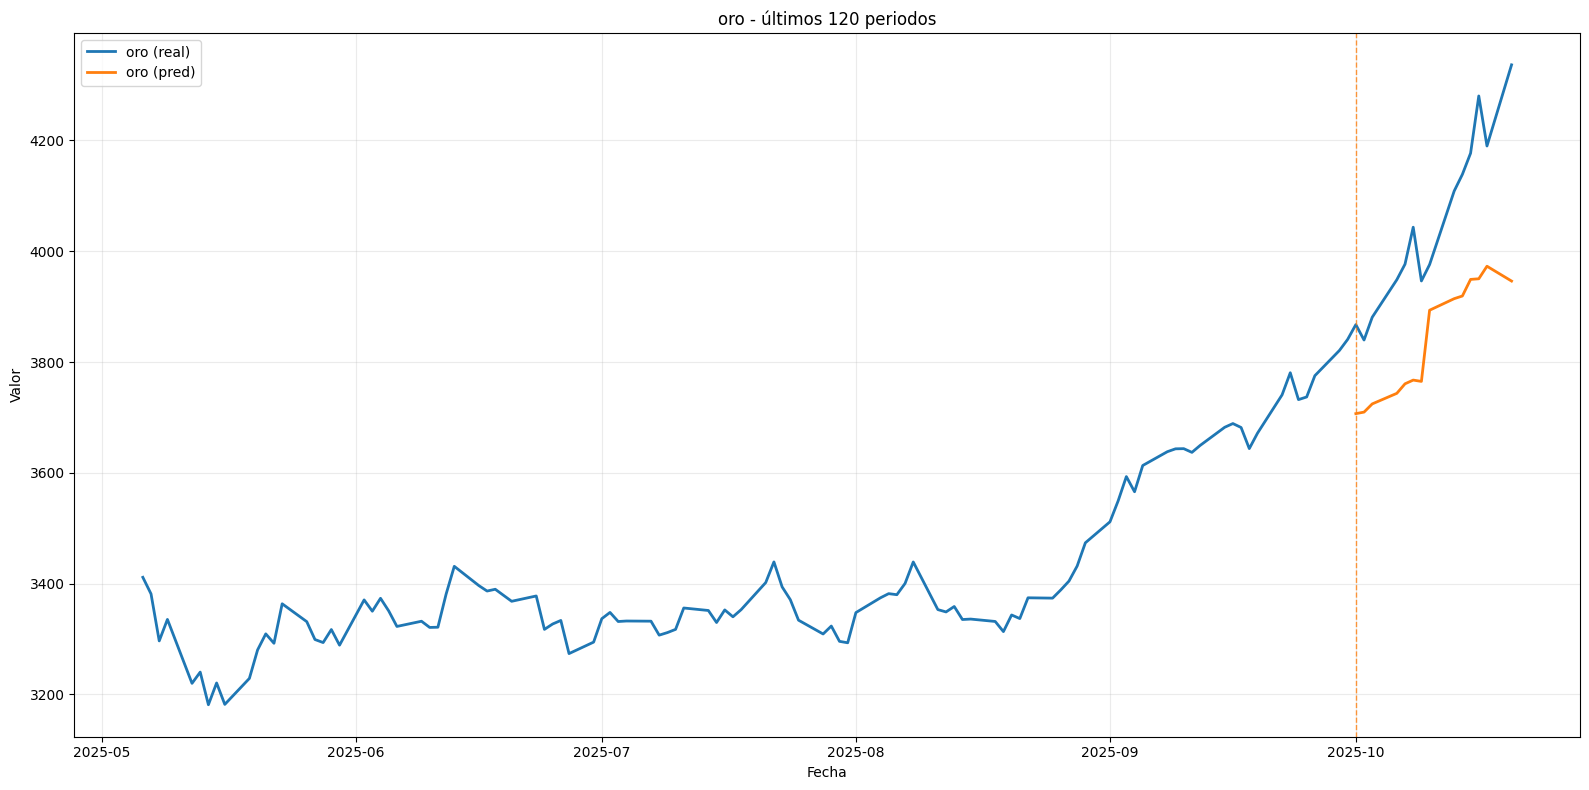

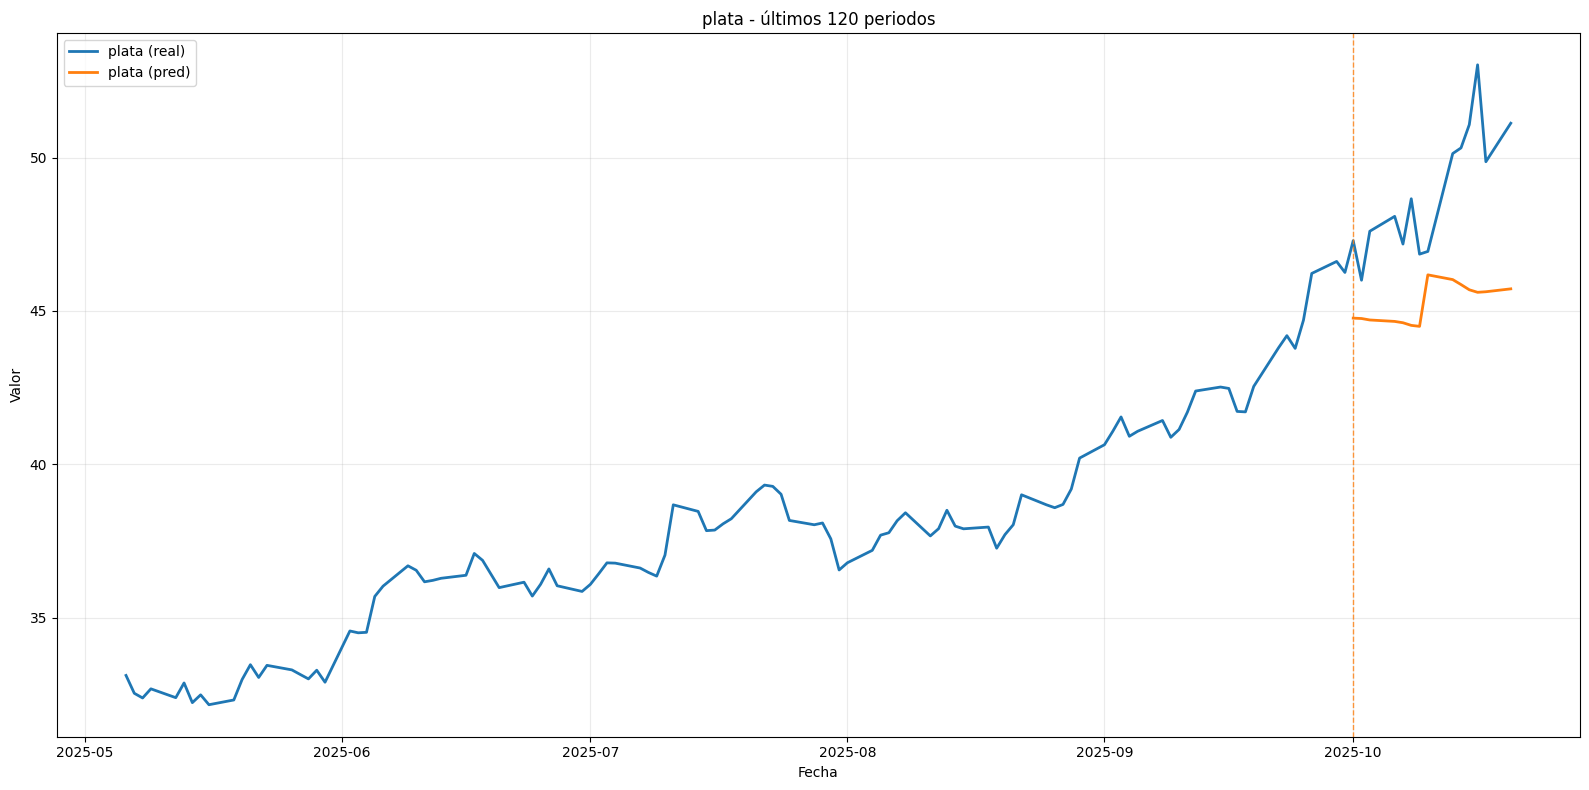

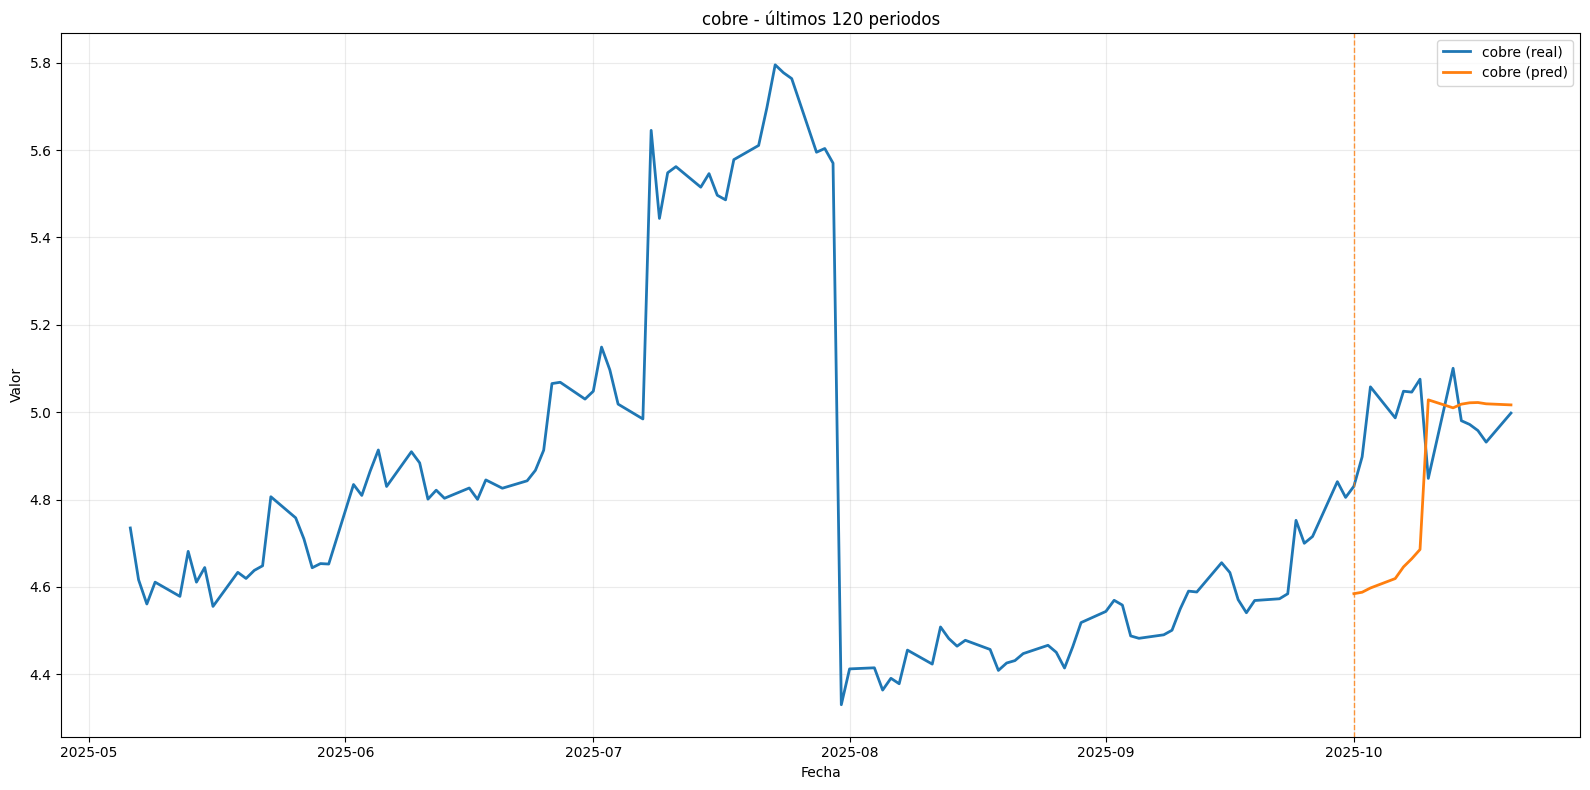

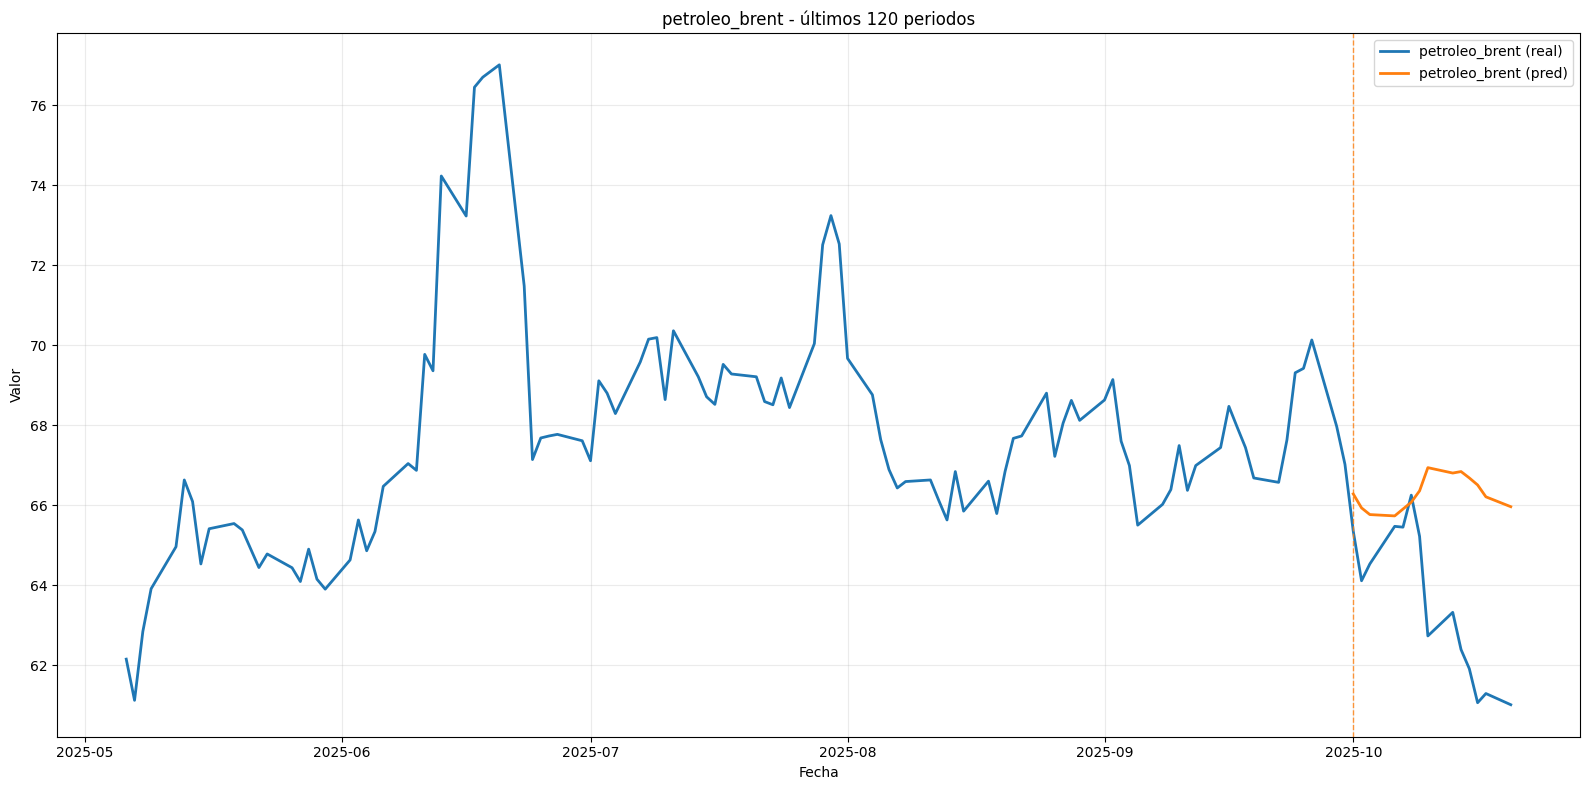

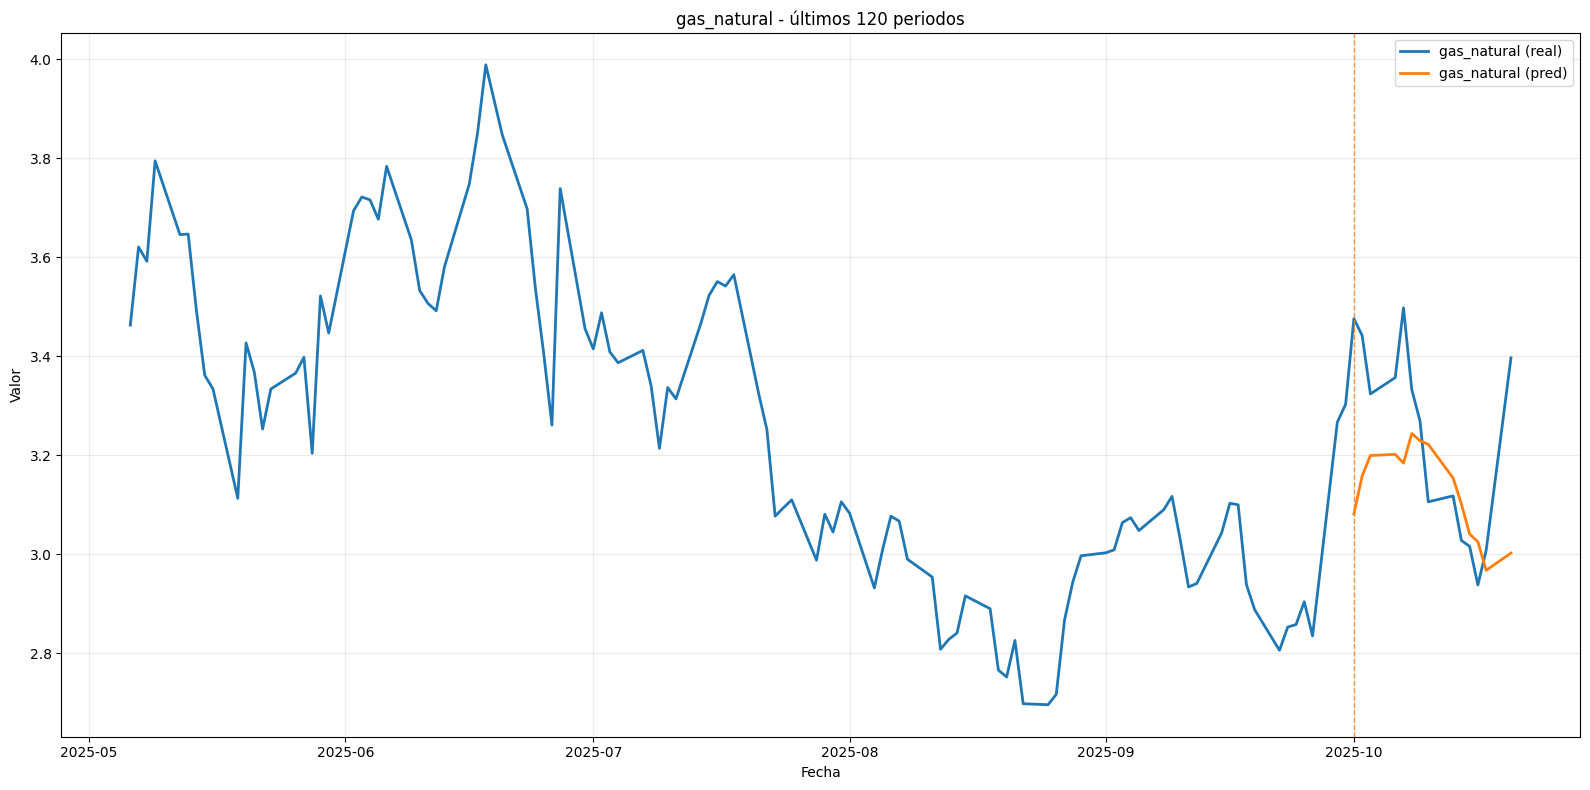

In [107]:
GRAFICA_COMMODITIES(df_y_pred, n_last=120)

## SARIMAX Robusto en base a mi modelo diario

In [147]:
# ============================================================
# MÉTRICAS Y UTILIDADES
# ============================================================
def _mape(y, yhat, eps=1e-9):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    denom = np.maximum(np.abs(y), eps)
    return float(np.mean(np.abs((y - yhat) / denom)) * 100.0)

def _rmse(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def _ensure_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    """
    - Si ya tiene DatetimeIndex, ordena.
    - Si no, intenta setear índice con una columna típica de fecha.
    - Robusto ante parseos fallidos (errors='coerce').
    - Elimina filas con fecha NaT.
    - Ordena y elimina índices duplicados.
    """
    df = df.copy()

    if not isinstance(df.index, pd.DatetimeIndex):
        for col in ["FECHA", "fecha", "Date", "date"]:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors="coerce")
                df = df.dropna(subset=[col]).set_index(col)
                break

    # Si por alguna razón aún no es DatetimeIndex, igual devolvemos ordenado
    df = df.sort_index()

    # Eliminar duplicados de índice (muy común en concatenaciones)
    if isinstance(df.index, pd.DatetimeIndex):
        df = df[~df.index.duplicated(keep="last")].sort_index()

    return df

def _numeric_cols(df: pd.DataFrame):
    return [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]


# ============================================================
# TRANSFORMACIONES (Box-Cox / Yeo-Johnson) + inversa
# ============================================================
def _inv_transform(y, transform_type, lmbda=None):
    y = np.asarray(y, dtype=float)
    tt = None if transform_type is None else str(transform_type).lower()

    if tt in (None, "none"):
        return y

    if tt == "log":
        return np.exp(y)

    if tt == "boxcox":
        if lmbda is None:
            raise ValueError("Se requiere lmbda para 'boxcox'.")
        if abs(lmbda) < 1e-10:
            return np.exp(y)
        val = y * lmbda + 1.0
        val = np.maximum(val, 1e-12)
        return val ** (1.0 / lmbda)

    if tt == "yeojohnson":
        if lmbda is None:
            raise ValueError("Se requiere lmbda para 'yeojohnson'.")
        x = np.zeros_like(y, dtype=float)
        pos = y >= 0

        if abs(lmbda) < 1e-10:
            x[pos] = np.expm1(y[pos])
        else:
            val = y[pos] * lmbda + 1.0
            val = np.maximum(val, 1e-12)
            x[pos] = val ** (1.0 / lmbda) - 1.0

        neg = ~pos
        if abs(lmbda - 2.0) < 1e-10:
            x[neg] = 1.0 - np.exp(-y[neg])
        else:
            val = 1.0 - y[neg] * (2.0 - lmbda)
            val = np.maximum(val, 1e-12)
            x[neg] = 1.0 - val ** (1.0 / (2.0 - lmbda))

        return x

    raise ValueError(f"transform_type '{transform_type}' no reconocido.")

def _fit_lambda_from_train(y_train, transform_type):
    """
    Ajusta lambda SOLO con train.
    Para boxcox: aplica shift si hay valores <= 0.
    """
    tt = None if transform_type is None else str(transform_type).lower()
    y = np.asarray(pd.Series(y_train).dropna().values, dtype=float)

    if tt in (None, "none"):
        return None, 0.0

    if tt == "yeojohnson":
        _, lmbda = stats.yeojohnson(y)
        return float(lmbda), 0.0

    if tt == "boxcox":
        miny = np.min(y)
        shift = 0.0
        if miny <= 0:
            shift = (-miny) + 1e-6
        y_pos = y + shift
        _, lmbda = stats.boxcox(y_pos)
        return float(lmbda), float(shift)

    raise ValueError(f"transform_type '{transform_type}' no reconocido.")

def _transform_with_fixed_lambda(y, transform_type, lmbda, shift=0.0):
    tt = None if transform_type is None else str(transform_type).lower()
    y = np.asarray(y, dtype=float)

    if tt in (None, "none"):
        return y

    if tt == "yeojohnson":
        return stats.yeojohnson(y, lmbda=lmbda)

    if tt == "boxcox":
        y_pos = y + shift
        y_pos = np.maximum(y_pos, 1e-12)
        return stats.boxcox(y_pos, lmbda=lmbda)

    raise ValueError(f"transform_type '{transform_type}' no reconocido.")

def _inv_transform_with_shift(y_t, transform_type, lmbda, shift=0.0):
    x = _inv_transform(y_t, transform_type, lmbda=lmbda)
    if (transform_type is not None) and (str(transform_type).lower() == "boxcox"):
        x = x - shift
    return x


# ============================================================
# SELECCIÓN DE EXÓGENAS
# ============================================================
def _select_exog_cols_fallback(df_train: pd.DataFrame, target_col: str, max_exog=None):
    num_cols = _numeric_cols(df_train)
    exog = [c for c in num_cols if c != target_col]
    if (max_exog is not None) and (len(exog) > int(max_exog)):
        exog = exog[: int(max_exog)]
    return exog

def _get_exog_cols(df_train: pd.DataFrame, target_col: str):
    """
    Si existe una función global _select_exog_cols(df_train, target_col, max_exog) la usa.
    Si no, usa fallback por columnas numéricas.
    """
    max_exog = globals().get("MAX_EXOG", None)
    if "_select_exog_cols" in globals() and callable(globals()["_select_exog_cols"]):
        return globals()["_select_exog_cols"](df_train, target_col, max_exog)
    return _select_exog_cols_fallback(df_train, target_col, max_exog=max_exog)


# ============================================================
# IMPUTACIÓN EXÓGENAS SIN LEAKAGE (CORREGIDA)
# ============================================================
def _prep_exog_history(df_hist: pd.DataFrame, exog_cols, df_train_base: pd.DataFrame):
    """
    SIN LEAKAGE:
    - Solo usa historia (ffill)
    - Medianas SOLO del train_base
    """
    if len(exog_cols) == 0:
        return None

    X = (
        df_hist.reindex(columns=exog_cols)
              .replace([np.inf, -np.inf], np.nan)
              .ffill()
    )

    med = (
        df_train_base.reindex(columns=exog_cols)
                     .replace([np.inf, -np.inf], np.nan)
                     .median(numeric_only=True)
    )

    X = X.fillna(med)
    return X


# ============================================================
# FUNCIÓN CORE: EVALUACIÓN ROLLING 21d (3x7) + WALK-FORWARD 1-step
# VERSIÓN SIN LEAKAGE + ROBUSTEZ EXTRA
# ============================================================
def evaluate_sarimax_rolling_21d(
    asset_name: str,
    sarimax_cfg: dict,
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    window_size: int = 7,
    n_windows: int = 3,
    save_globals: bool = True,
):
    df_train = _ensure_datetime_index(df_train)
    df_test  = _ensure_datetime_index(df_test)

    if asset_name not in df_train.columns:
        raise ValueError(f"'{asset_name}' no está en df_train.columns")
    if asset_name not in df_test.columns:
        raise ValueError(f"'{asset_name}' no está en df_test.columns")

    order = tuple(sarimax_cfg["order"])
    seasonal_order = tuple(sarimax_cfg["seasonal_order"])
    transform_type = sarimax_cfg.get("transform", None)

    # Exógenas definidas SOLO desde train
    exog_cols = _get_exog_cols(df_train, asset_name)

    # --- CORRECCIÓN: asegurar que exog_cols existan en test también ---
    if len(exog_cols) > 0:
        missing = [c for c in exog_cols if c not in df_test.columns]
        if missing:
            print(f"[WARN] {asset_name}: exógenas faltantes en df_test, se eliminan: {missing}")
            exog_cols = [c for c in exog_cols if c in df_test.columns]

    # 21 días = 3 ventanas * 7 días (por defecto)
    K = min(len(df_test), int(window_size) * int(n_windows))
    w_used = K // int(window_size)
    if w_used < 1:
        raise ValueError("df_test no tiene suficientes puntos para al menos 1 ventana completa.")
    df_test_eval = df_test.iloc[: w_used * int(window_size)].copy()

    # Transformación: lambda/shift SOLO con train
    lmbda, shift = _fit_lambda_from_train(df_train[asset_name].values, transform_type)

    preds_all = []
    window_ids = []
    step_in_window = []
    rows_windows = []

    # === Rolling por ventanas ===
    for w in range(w_used):
        a = w * int(window_size)
        b = (w + 1) * int(window_size)
        df_test_w = df_test_eval.iloc[a:b]

        # Expanding entre ventanas: train + pasado observado (hasta a)
        df_train_w = pd.concat([df_train, df_test_eval.iloc[:a]], axis=0)
        df_train_w = df_train_w[~df_train_w.index.duplicated(keep="last")].sort_index()

        # --- WALK-FORWARD 1-step dentro de la ventana ---
        # Guardamos historia target + historia exog (solo revelamos exog después de predecir)
        df_hist_target = df_train_w[[asset_name]].copy()

        if len(exog_cols) > 0:
            # historia exog hasta el punto actual (viene solo de train_w al inicio)
            df_hist_exog = df_train_w[exog_cols].copy()
        else:
            df_hist_exog = pd.DataFrame(index=df_hist_target.index)

        fc_window = []

        for t in range(len(df_test_w)):
            # y hist transformada
            y_hist_orig = df_hist_target[asset_name].astype(float).values
            y_hist_t = _transform_with_fixed_lambda(y_hist_orig, transform_type, lmbda, shift=shift)
            y_hist_t = pd.Series(y_hist_t, index=df_hist_target.index)

            # X hist: SOLO exógenas conocidas a la fecha (ffill) + mediana de train
            if len(exog_cols) > 0:
                df_hist_combined = pd.concat([df_hist_target, df_hist_exog], axis=1)
                X_hist = _prep_exog_history(df_hist_combined, exog_cols, df_train_base=df_train)

                # --- CORRECCIÓN: alinear índice exog con endog ---
                X_hist = X_hist.reindex(y_hist_t.index)
            else:
                X_hist = None

            try:
                fit_step = SARIMAX(
                    y_hist_t,
                    exog=X_hist if (X_hist is not None and X_hist.shape[1] > 0) else None,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                ).fit(disp=False, maxiter=200, method="lbfgs")

                # Exog para el próximo día: last-known (NO futuro)
                X_next = None
                if X_hist is not None and X_hist.shape[1] > 0:
                    last_known = X_hist.iloc[-1].values.reshape(1, -1)
                    X_next = pd.DataFrame(last_known, columns=X_hist.columns)

                fc_t = fit_step.forecast(steps=1, exog=X_next)
                fc_orig = _inv_transform_with_shift(np.asarray(fc_t), transform_type, lmbda, shift=shift)[0]

            except Exception:
                # Fallback: último valor observado
                fc_orig = float(y_hist_orig[-1])

            fc_window.append(float(fc_orig))

            # Revelamos el TARGET real del día t (ya predijimos)
            new_target_row = pd.DataFrame(
                {asset_name: [df_test_w[asset_name].iloc[t]]},
                index=[df_test_w.index[t]]
            )
            df_hist_target = pd.concat([df_hist_target, new_target_row], axis=0)
            df_hist_target = df_hist_target[~df_hist_target.index.duplicated(keep="last")].sort_index()

            # Revelamos EXÓGENAS reales del día t (ya predijimos, por tanto NO leakage)
            if len(exog_cols) > 0:
                # Si por algún motivo faltara alguna exógena en esta fila, reindexa seguro
                row_exog = df_test_w.iloc[t].reindex(exog_cols)
                row_exog = row_exog.replace([np.inf, -np.inf], np.nan)

                new_exog_row = pd.DataFrame(
                    [row_exog.values],
                    columns=exog_cols,
                    index=[df_test_w.index[t]]
                )

                df_hist_exog = pd.concat([df_hist_exog, new_exog_row], axis=0)
                df_hist_exog = df_hist_exog[~df_hist_exog.index.duplicated(keep="last")].sort_index()

        fc_window = np.asarray(fc_window, dtype=float)
        y_true_w = df_test_w[asset_name].astype(float).values

        preds_all.append(fc_window.reshape(-1))
        window_ids.extend([w + 1] * len(df_test_w))
        step_in_window.extend(list(range(1, len(df_test_w) + 1)))

        rows_windows.append({
            "window_id": w + 1,
            "start_date": df_test_w.index[0],
            "end_date": df_test_w.index[-1],
            "n_points": int(len(df_test_w)),
            "mape": _mape(y_true_w, fc_window),
            "rmse": _rmse(y_true_w, fc_window),
        })

    # Consolidar resultados
    y_pred_all = np.concatenate(preds_all, axis=0)
    y_true_all = df_test_eval[asset_name].astype(float).values
    idx = df_test_eval.index

    df_res = pd.DataFrame(
        {
            "asset": asset_name,
            "y_true": y_true_all,
            "y_pred": y_pred_all,
            "window_id": window_ids,
            "step_in_window": step_in_window,
        },
        index=idx
    )

    df_windows = pd.DataFrame(rows_windows)
    mape_avg_windows = float(df_windows["mape"].mean())
    rmse_avg_windows = float(df_windows["rmse"].mean())

    mape_global = _mape(df_res["y_true"].values, df_res["y_pred"].values)
    rmse_global = _rmse(df_res["y_true"].values, df_res["y_pred"].values)

    if save_globals:
        globals()[f"df_predicciones_sarimax_{asset_name}"] = df_res
        globals()[f"df_metrics_windows_sarimax_{asset_name}"] = df_windows
        globals()[f"metrics_summary_sarimax_{asset_name}"] = {
            "asset": asset_name,
            "order": order,
            "seasonal_order": seasonal_order,
            "transform": transform_type,
            "lambda": lmbda,
            "shift": shift,
            "window_size": int(window_size),
            "n_windows_used": int(len(df_windows)),
            "mape_avg_windows": mape_avg_windows,
            "rmse_avg_windows": rmse_avg_windows,
            "mape_global": mape_global,
            "rmse_global": rmse_global,
            "n_exog": int(len(exog_cols)),
        }

    return df_res, mape_avg_windows, rmse_avg_windows, df_windows


# ============================================================
# CONFIGURACIÓN SARIMAX
# ============================================================
SARIMAX_DAILY_CFG = {
    "oro": {
        "order": (0, 1, 0),
        "seasonal_order": (2, 0, 2, 5),
        "transform": "yeojohnson",
    },
    "plata": {
        "order": (1, 1, 1),
        "seasonal_order": (1, 0, 0, 5),
        "transform": "yeojohnson",
    },
    "cobre": {
        "order": (3, 1, 1),
        "seasonal_order": (0, 0, 0, 5),
        "transform": "boxcox",
    },
    "gas_natural": {
        "order": (1, 1, 0),
        "seasonal_order": (2, 0, 2, 5),
        "transform": "yeojohnson",
    },
    "petroleo_brent": {
        "order": (0, 1, 2),
        "seasonal_order": (0, 0, 1, 5),
        "transform": "yeojohnson",
    },
}


# ============================================================
# RUNNER PARA TODOS LOS COMMODITIES
# ============================================================
def run_sarimax_rolling_for_all(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    configs: dict = None,
    window_size: int = 7,
    n_windows: int = 3,
):
    df_train = _ensure_datetime_index(df_train)
    df_test  = _ensure_datetime_index(df_test)

    if configs is None:
        configs = SARIMAX_DAILY_CFG

    alias_map = {
        "gas": "gas_natural",
        "petroleo": "petroleo_brent",
        "brent": "petroleo_brent",
    }

    preds_long = []
    summary_rows = []

    for key, cfg in configs.items():
        asset_col = key

        # alias nombres de columna
        if asset_col not in df_train.columns:
            if key in alias_map and alias_map[key] in df_train.columns:
                asset_col = alias_map[key]
            else:
                inv = {v: k for k, v in alias_map.items()}
                if key in inv and inv[key] in df_train.columns:
                    asset_col = inv[key]
                else:
                    print(f"[WARN] No se encontró columna para '{key}'. Saltando...")
                    continue

        print(f"Evaluando SARIMAX (SIN leakage) para: {asset_col} ...")

        df_res, mape_avg, rmse_avg, df_w = evaluate_sarimax_rolling_21d(
            asset_name=asset_col,
            sarimax_cfg=cfg,
            df_train=df_train,
            df_test=df_test,
            window_size=window_size,
            n_windows=n_windows,
            save_globals=True
        )

        preds_long.append(df_res.reset_index(names="date"))

        summ = globals().get(f"metrics_summary_sarimax_{asset_col}", {})
        summary_rows.append({
            "asset": asset_col,
            "mape_avg_windows": mape_avg,
            "rmse_avg_windows": rmse_avg,
            "mape_global": summ.get("mape_global", np.nan),
            "rmse_global": summ.get("rmse_global", np.nan),
            "order": cfg["order"],
            "seasonal_order": cfg["seasonal_order"],
            "transform": cfg.get("transform", None),
            "lambda": summ.get("lambda", np.nan),
            "shift": summ.get("shift", np.nan),
            "n_exog": summ.get("n_exog", np.nan),
            "window_size": int(window_size),
            "n_windows": int(n_windows),
        })

    df_pred_all = pd.concat(preds_long, axis=0, ignore_index=True) if preds_long else pd.DataFrame()
    df_summary  = pd.DataFrame(summary_rows).sort_values(["asset"]) if summary_rows else pd.DataFrame()

    return df_pred_all, df_summary


# ============================================================
# MÉTRICAS (públicas)
# ============================================================
def mape(y, yhat, eps=1e-9):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    denom = np.maximum(np.abs(y), eps)
    return float(np.mean(np.abs((y - yhat) / denom)) * 100)

def rmse(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))


In [148]:
df_sarimax_pred_all, df_sarimax_summary = run_sarimax_rolling_for_all(
    df_train=df_consol_train,
    df_test=df_consol_test,
    configs=SARIMAX_DAILY_CFG,  
    window_size=7,
    n_windows=3
)

display(df_sarimax_summary)
display(df_sarimax_pred_all.head(30))

Evaluando SARIMAX (SIN leakage) para: oro ...
Evaluando SARIMAX (SIN leakage) para: plata ...
Evaluando SARIMAX (SIN leakage) para: cobre ...
Evaluando SARIMAX (SIN leakage) para: gas_natural ...
Evaluando SARIMAX (SIN leakage) para: petroleo_brent ...


,asset,mape_avg_windows,rmse_avg_windows,mape_global,rmse_global,order,seasonal_order,transform,lambda,shift,n_exog,window_size,n_windows
2,cobre,1.344586,0.089458,1.344586,0.094779,"(3, 1, 1)","(0, 0, 0, 5)",boxcox,0.878404,0.0,20,7,3
3,gas_natural,3.118633,0.131044,3.118633,0.133763,"(1, 1, 0)","(2, 0, 2, 5)",yeojohnson,-1.114970,0.0,20,7,3
0,oro,1.667899,86.594745,1.667899,89.395569,"(0, 1, 0)","(2, 0, 2, 5)",yeojohnson,-0.336585,0.0,21,7,3
4,petroleo_brent,1.404804,1.215793,1.404804,1.236678,"(0, 1, 2)","(0, 0, 1, 5)",yeojohnson,0.625873,0.0,19,7,3
1,plata,2.681108,1.627978,2.681108,1.652343,"(1, 1, 1)","(1, 0, 0, 5)",yeojohnson,-0.475837,0.0,21,7,3


,date,asset,y_true,y_pred,window_id,step_in_window
0,2025-10-01,oro,3867.500000,3840.931449,1,1
1,2025-10-02,oro,3839.699951,3867.393484,1,2
2,2025-10-03,oro,3880.800049,3839.551730,1,3
3,2025-10-06,oro,3948.500000,3880.530093,1,4
4,2025-10-07,oro,3976.600098,3948.424175,1,5
5,2025-10-08,oro,4043.300049,3976.681594,1,6
6,2025-10-09,oro,3946.300049,4043.346064,1,7
7,2025-10-10,oro,3975.899902,3945.966970,2,1
8,2025-10-13,oro,4108.600098,3976.043418,2,2
9,2025-10-14,oro,4138.700195,4108.471435,2,3


In [149]:
df_sarimax_pred_all["MAPE"]=abs((df_sarimax_pred_all["y_true"]-df_sarimax_pred_all["y_pred"])/df_sarimax_pred_all["y_true"])

In [150]:
mape_promedio_por_asset = df_sarimax_pred_all.groupby("asset")["MAPE"].mean()
mape_promedio_por_asset

asset
cobre             0.013446
gas_natural       0.031186
oro               0.016679
petroleo_brent    0.014048
plata             0.026811
Name: MAPE, dtype: float64

In [166]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import random
import copy
import time
from itertools import product
from typing import Dict, List, Tuple, Optional

# =========================
# CONFIG RÁPIDA (para ~1h)
# =========================
DEVICE = torch.device("cuda")  # RTX

TEST_MONTHS = 3
HORIZON = 10        # 10 días
VAL_SIZE = 10       # validación 10 días
BLOCK_SIZE = 10     # reentrena cada 10 días en test

# GRID SEARCH (rápido)
N_FOLDS_SEARCH = 3
SEEDS_SEARCH = (42,)          # 1 seed
N_CONFIGS = 460                # <- clave para ~1h

# TEST (barato, puedes dejar 3 seeds para CI)
SEEDS_TEST = (42, 333, 777)

# Speed-up cuDNN (no determinístico)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

# =========================
# UTILS
# =========================
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-9) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)

def safe_log_returns(price: pd.Series) -> pd.Series:
    s = price.astype(float)
    if (s <= 0).any():
        raise ValueError("Hay precios <= 0. Log-return requiere precios positivos.")
    return np.log(s).diff()

def returns_to_prices(last_price: float, log_returns: np.ndarray) -> np.ndarray:
    return last_price * np.exp(np.cumsum(log_returns))

# =========================
# SPLIT: últimos 3 meses a test
# =========================
def split_last_months(df_full: pd.DataFrame, months: int = 3) -> Tuple[pd.DataFrame, pd.DataFrame]:
    df_full = df_full.sort_index().copy()
    cutoff = df_full.index.max() - pd.DateOffset(months=months)
    df_train = df_full.loc[df_full.index < cutoff].copy()
    df_test  = df_full.loc[df_full.index >= cutoff].copy()
    return df_train, df_test

# =========================
# BUILD X + RETURNS + PRICES (sin colisiones)
# =========================
def build_X_returns_prices(
    df: pd.DataFrame,
    target_cols: List[str],
    extra_feature_cols: Optional[List[str]] = None,
    include_target_returns_in_X: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    df = df.sort_index().copy()

    if df.columns.duplicated().any():
        dups = df.columns[df.columns.duplicated()].tolist()
        raise ValueError(f"Tu df de entrada ya trae columnas duplicadas: {dups}")

    df_prices = df[target_cols].astype(float)

    ret_cols = [f"{c}__ret" for c in target_cols]
    df_ret = pd.DataFrame(
        {f"{c}__ret": safe_log_returns(df_prices[c]) for c in target_cols},
        index=df.index
    )

    if extra_feature_cols is None:
        num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        extra_feature_cols = [c for c in num_cols if c not in target_cols]
    df_extra = df[extra_feature_cols].copy()

    # Nota: dropna sobre TODO (extra+prices+ret). Si pierdes demasiadas filas, hay que imputar exógenas.
    df_align = pd.concat([df_extra, df_prices, df_ret], axis=1).dropna(axis=0)

    df_prices_al = df_align[target_cols].astype(float)

    df_ret_al = df_align[ret_cols].astype(float).copy()
    df_ret_al.columns = target_cols

    if include_target_returns_in_X:
        df_X = pd.concat([df_ret_al.add_suffix("__ret_inX"), df_align[df_extra.columns]], axis=1)
    else:
        df_X = df_align[df_extra.columns]

    return df_X, df_ret_al, df_prices_al

# =========================
# SEQUENCES
# =========================
def create_sequences_multioutput(
    X_scaled: np.ndarray, Y_scaled: np.ndarray, timesteps: int, horizon: int
) -> Tuple[np.ndarray, np.ndarray]:
    N = len(X_scaled)
    last = N - timesteps - horizon
    X_seq, Y_seq = [], []
    for i in range(last + 1):
        X_seq.append(X_scaled[i:i+timesteps, :])               # (T,F)
        y_block = Y_scaled[i+timesteps:i+timesteps+horizon, :] # (H,A)
        Y_seq.append(y_block.T)                                # (A,H)
    return np.asarray(X_seq), np.asarray(Y_seq)

def make_forecast_input(X_scaled: np.ndarray, end_idx: int, timesteps: int) -> np.ndarray:
    s = end_idx - timesteps
    if s < 0:
        raise ValueError("No hay suficientes timesteps para armar la ventana.")
    return X_scaled[s:end_idx, :][None, :, :]  # (1,T,F)

# =========================
# DATASET
# =========================
class MultiOutSeqDataset(Dataset):
    def __init__(self, X_seq: np.ndarray, Y_seq: np.ndarray):
        self.X = torch.tensor(X_seq, dtype=torch.float32)
        self.Y = torch.tensor(Y_seq, dtype=torch.float32)
    def __len__(self) -> int:
        return self.X.shape[0]
    def __getitem__(self, idx: int):
        return self.X[idx], self.Y[idx]

# =========================
# MODEL (bidirectional SIEMPRE False)
# =========================
class MultiOutLSTM(nn.Module):
    def __init__(self, input_dim: int, n_assets: int, horizon: int,
                 hidden_size: int = 128, num_layers: int = 2, dropout: float = 0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )
        self.drop = nn.Dropout(dropout)
        self.heads = nn.ModuleList([nn.Linear(hidden_size, horizon) for _ in range(n_assets)])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)              # (B,T,H)
        h = self.drop(out[:, -1, :])       # (B,H)
        yhat = torch.stack([head(h) for head in self.heads], dim=1)  # (B,A,Horizon)
        return yhat

# =========================
# ROLLING ORIGIN FOLDS
# =========================
def rolling_origin_folds(n: int, n_folds: int, val_size: int, min_train: int = 200) -> List[Tuple[int, int]]:
    folds = []
    for k in range(n_folds):
        val_end = n - (n_folds - 1 - k) * val_size
        val_start = val_end - val_size
        train_end = val_start
        if train_end >= min_train:
            folds.append((train_end, val_end))
    return folds

# =========================
# TRAIN (rápido: epochs/patience bajos)
# =========================
def train_model(X_seq: np.ndarray, Y_seq: np.ndarray, cfg: Dict, seed: int) -> MultiOutLSTM:
    set_seed(seed)

    model = MultiOutLSTM(
        input_dim=X_seq.shape[-1],
        n_assets=int(cfg["n_assets"]),
        horizon=int(cfg["horizon"]),
        hidden_size=int(cfg.get("hidden_size", 128)),
        num_layers=int(cfg.get("num_layers", 2)),
        dropout=float(cfg.get("dropout", 0.2)),
    ).to(DEVICE)

    # early-stop interno: último 10% de secuencias
    val_frac = float(cfg.get("internal_val_frac", 0.10))
    n = len(X_seq)
    n_val = max(1, int(n * val_frac)) if n > 30 else 0

    if n_val > 0:
        X_tr, Y_tr = X_seq[:-n_val], Y_seq[:-n_val]
        X_va, Y_va = X_seq[-n_val:], Y_seq[-n_val:]
    else:
        X_tr, Y_tr = X_seq, Y_seq
        X_va, Y_va = None, None

    bs = int(cfg.get("batch_size", 64))
    train_loader = DataLoader(MultiOutSeqDataset(X_tr, Y_tr), batch_size=bs, shuffle=True, num_workers=0)

    val_loader = None
    if X_va is not None:
        val_loader = DataLoader(MultiOutSeqDataset(X_va, Y_va), batch_size=bs, shuffle=False, num_workers=0)

    criterion = nn.MSELoss()
    opt = torch.optim.Adam(
        model.parameters(),
        lr=float(cfg.get("lr", 1e-3)),
        weight_decay=float(cfg.get("weight_decay", 0.0))
    )

    max_epochs = int(cfg.get("epochs", 30))
    patience = int(cfg.get("patience", 5))
    min_delta = float(cfg.get("min_delta", 1e-5))

    best_state = None
    best_val = float("inf")
    bad = 0

    for _ in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            yhat = model(xb)
            loss = criterion(yhat, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

        if val_loader is None:
            continue

        model.eval()
        with torch.no_grad():
            vals = []
            for xb, yb in val_loader:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                yhat = model(xb)
                vals.append(criterion(yhat, yb).item())
            v = float(np.mean(vals)) if vals else float("inf")

        if v + min_delta < best_val:
            best_val = v
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

# =========================
# GRILLA RÁPIDA (acotada pero grande)
# =========================
def build_param_grid_sampled_fast(n_samples=360, seed=42):
    rng = np.random.default_rng(seed)

    timesteps_list    = [5,10,20,30, 45, 60]
    hidden_size_list  = [96, 128]
    num_layers_list   = [2]
    dropout_list      = [0.15, 0.20]
    lr_list           = [1e-4, 3e-4, 5e-4, 1e-3, 1e-5]
    batch_size_list   = [32,64, 128]              
    weight_decay_list = [1e-4]

    # epochs/patience bajos (rápido)
    def epochs_for(L):   return 20 if L == 1 else (25 if L == 2 else 30)
    def patience_for(L): return 3  if L == 1 else (4  if L == 2 else 5)

    all_cfgs = []
    for T, H, L, D, LR, BS, WD in product(
        timesteps_list, hidden_size_list, num_layers_list, dropout_list,
        lr_list, batch_size_list, weight_decay_list
    ):
        if L == 3 and H < 96:
            continue

        all_cfgs.append({
            "timesteps": int(T),
            "hidden_size": int(H),
            "num_layers": int(L),
            "dropout": float(D),
            "lr": float(LR),
            "batch_size": int(BS),
            "weight_decay": float(WD),
            "epochs": int(epochs_for(L)),
            "patience": int(patience_for(L)),
            "internal_val_frac": 0.10,
        })

    space_size = len(all_cfgs)
    n_samples = min(int(n_samples), space_size)
    idx = rng.choice(space_size, size=n_samples, replace=False)
    sampled = [all_cfgs[i] for i in idx]
    return sampled, space_size

# =========================
# GRID SEARCH (selección por CV MAPE en PRECIO) + PROGRESO
# =========================
def grid_search_multitarget_by_val_mape(
    df_train: pd.DataFrame,
    target_cols: List[str],
    param_grid: List[Dict],
    seeds: Tuple[int, ...],
    horizon: int,
    val_size: int,
    n_folds: int,
    include_target_returns_in_X: bool = True,
) -> pd.DataFrame:

    df_X, df_ret, df_prices = build_X_returns_prices(
        df_train, target_cols,
        extra_feature_cols=None,
        include_target_returns_in_X=include_target_returns_in_X
    )

    X_full = df_X.values.astype(float)
    R_full = df_ret.values.astype(float)
    P_full = df_prices.values.astype(float)

    n, n_assets = R_full.shape
    folds = rolling_origin_folds(n, n_folds=n_folds, val_size=val_size, min_train=max(200, 4*val_size + 2*horizon))
    if len(folds) == 0:
        raise ValueError("No hay suficientes datos (post-alineación) para CV rolling-origin.")

    rows = []
    t0 = time.time()

    for cfg_id, base in enumerate(param_grid):
        cfg = dict(base)
        cfg["horizon"] = int(horizon)
        cfg["n_assets"] = int(n_assets)
        timesteps = int(cfg.get("timesteps", 30))

        fold_mapes, fold_rmses = [], []

        for train_end, val_end in folds:
            X_scaler = StandardScaler().fit(X_full[:train_end, :])
            X_sc = X_scaler.transform(X_full[:val_end, :])

            y_scalers = []
            R_sc = np.zeros_like(R_full[:val_end, :], dtype=float)
            for j in range(n_assets):
                sc = StandardScaler().fit(R_full[:train_end, j].reshape(-1, 1))
                y_scalers.append(sc)
                R_sc[:, j] = sc.transform(R_full[:val_end, j].reshape(-1, 1)).reshape(-1)

            X_train_seq, Y_train_seq = create_sequences_multioutput(
                X_sc[:train_end, :], R_sc[:train_end, :], timesteps, horizon
            )
            if len(X_train_seq) < 30:
                continue

            x_in = make_forecast_input(X_sc, end_idx=train_end, timesteps=timesteps)
            x_in_t = torch.tensor(x_in, dtype=torch.float32, device=DEVICE)

            eval_H = min(horizon, val_size)
            true_prices = P_full[train_end:train_end+eval_H, :]

            seed_mape, seed_rmse = [], []
            for seed in seeds:
                model = train_model(X_train_seq, Y_train_seq, cfg, seed)
                model.eval()
                with torch.no_grad():
                    yhat_sc = model(x_in_t).detach().cpu().numpy().reshape(n_assets, horizon)  # (A,H)

                pred_prices = np.zeros((eval_H, n_assets), float)
                for j in range(n_assets):
                    mean = float(y_scalers[j].mean_[0])
                    scale = float(y_scalers[j].scale_[0])
                    yhat_ret = yhat_sc[j, :eval_H] * scale + mean
                    last_p = float(P_full[train_end - 1, j])
                    pred_prices[:, j] = returns_to_prices(last_p, yhat_ret)

                seed_rmse.append(float(np.mean([rmse(true_prices[:, j], pred_prices[:, j]) for j in range(n_assets)])))
                seed_mape.append(float(np.mean([mape(true_prices[:, j], pred_prices[:, j]) for j in range(n_assets)])))

            fold_rmses.append(float(np.mean(seed_rmse)))
            fold_mapes.append(float(np.mean(seed_mape)))

        cv_rmse = float(np.mean(fold_rmses)) if fold_rmses else float("inf")
        cv_mape = float(np.mean(fold_mapes)) if fold_mapes else float("inf")

        rows.append({
            "cfg_id": cfg_id,
            "cv_mape_price": cv_mape,
            "cv_rmse_price": cv_rmse,
            **cfg
        })

        # progreso + ETA
        done = cfg_id + 1
        total = len(param_grid)
        elapsed = time.time() - t0
        per_cfg = elapsed / done
        eta = per_cfg * (total - done)
        print(f"[{done}/{total}] cv_mape={cv_mape:.4f} | elapsed={elapsed/60:.1f}m | ETA={eta/60:.1f}m")

    return pd.DataFrame(rows).sort_values("cv_mape_price").reset_index(drop=True)

# =========================
# TEST: últimos 3 meses, reentrena cada 10 días (expanding) + CI
# =========================
def evaluate_rolling_test_last_months(
    df_train_pretest: pd.DataFrame,
    df_test_3m: pd.DataFrame,
    target_cols: List[str],
    best_cfg: Dict,
    seeds: Tuple[int, ...],
    horizon: int,
    block_size: int,
    include_target_returns_in_X: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:

    df_total = pd.concat([df_train_pretest, df_test_3m]).sort_index()

    df_X, df_ret, df_prices = build_X_returns_prices(
        df_total, target_cols,
        extra_feature_cols=None,
        include_target_returns_in_X=include_target_returns_in_X
    )

    X_full = df_X.values.astype(float)
    R_full = df_ret.values.astype(float)
    P_full = df_prices.values.astype(float)
    idx = df_X.index

    n, n_assets = R_full.shape
    timesteps = int(best_cfg.get("timesteps", 30))
    H = int(horizon)
    step = int(block_size)

    test_start_date = df_test_3m.index.min()
    test_start_idx = int(idx.searchsorted(test_start_date))
    if test_start_idx <= 0:
        raise ValueError("test_start_idx inválido (<=0) luego de alinear por retornos.")

    # largo test (en índice alineado)
    test_len = len(idx[test_start_idx: idx.searchsorted(df_test_3m.index.max(), side="right")])
    test_len = int(max(1, test_len))

    actual = P_full[test_start_idx:test_start_idx + test_len, :]
    pred_mu = np.zeros_like(actual)
    pred_lo = np.zeros_like(actual)
    pred_hi = np.zeros_like(actual)

    pos = test_start_idx
    out_pos = 0

    while out_pos < test_len:
        train_end = pos
        remaining = test_len - out_pos
        eval_H = min(step, remaining)
        w_end = train_end + eval_H

        X_scaler = StandardScaler().fit(X_full[:train_end, :])
        X_sc = X_scaler.transform(X_full[:w_end, :])

        y_scalers = []
        for j in range(n_assets):
            sc = StandardScaler().fit(R_full[:train_end, j].reshape(-1, 1))
            y_scalers.append(sc)

        R_sc_train = np.zeros((train_end, n_assets), float)
        for j in range(n_assets):
            R_sc_train[:, j] = y_scalers[j].transform(R_full[:train_end, j].reshape(-1, 1)).reshape(-1)

        X_train_seq, Y_train_seq = create_sequences_multioutput(X_sc[:train_end, :], R_sc_train, timesteps, H)
        if len(X_train_seq) < 30:
            raise ValueError(f"Pocas secuencias en test rolling. Reduce timesteps. n_seq={len(X_train_seq)}")

        x_in = make_forecast_input(X_sc, end_idx=train_end, timesteps=timesteps)
        x_in_t = torch.tensor(x_in, dtype=torch.float32, device=DEVICE)

        seed_preds = []
        for seed in seeds:
            cfg = dict(best_cfg)
            cfg["horizon"] = H
            cfg["n_assets"] = n_assets

            model = train_model(X_train_seq, Y_train_seq, cfg, seed)
            model.eval()
            with torch.no_grad():
                yhat_sc_full = model(x_in_t).detach().cpu().numpy().reshape(n_assets, H)

            preds_prices = np.zeros((eval_H, n_assets), float)
            for j in range(n_assets):
                mean = float(y_scalers[j].mean_[0])
                scale = float(y_scalers[j].scale_[0])
                yhat_ret = yhat_sc_full[j, :eval_H] * scale + mean
                last_p = float(P_full[train_end - 1, j])
                preds_prices[:, j] = returns_to_prices(last_p, yhat_ret)

            seed_preds.append(preds_prices)

        seed_preds = np.stack(seed_preds, axis=0)  # (S, eval_H, A)
        mu = seed_preds.mean(axis=0)
        sd = seed_preds.std(axis=0, ddof=1) if seed_preds.shape[0] > 1 else np.zeros_like(mu)
        lo = mu - 1.96 * sd
        hi = mu + 1.96 * sd

        sl = slice(out_pos, out_pos + eval_H)
        pred_mu[sl, :] = mu
        pred_lo[sl, :] = lo
        pred_hi[sl, :] = hi

        pos += eval_H
        out_pos += eval_H

    test_dates = idx[test_start_idx:test_start_idx + test_len]
    data = {}
    for j, a in enumerate(target_cols):
        data[(a, "actual")] = actual[:, j]
        data[(a, "pred")]   = pred_mu[:, j]
        data[(a, "lo")]     = pred_lo[:, j]
        data[(a, "hi")]     = pred_hi[:, j]

    df_pred = pd.DataFrame(data, index=test_dates)
    df_pred.columns = pd.MultiIndex.from_tuples(df_pred.columns, names=["asset", "type"])

    rows = []
    rmses, mapes_ = [], []
    for a in target_cols:
        y_t = df_pred[(a, "actual")].values
        y_p = df_pred[(a, "pred")].values
        r = rmse(y_t, y_p)
        m = mape(y_t, y_p)
        rows.append({"asset": a, "rmse_price": r, "mape_price": m})
        rmses.append(r); mapes_.append(m)

    rows.append({"asset": "PROMEDIO", "rmse_price": float(np.mean(rmses)), "mape_price": float(np.mean(mapes_))})
    df_metrics = pd.DataFrame(rows)

    return df_pred, df_metrics

# ============================================================
# ============================ USO ============================
# ============================================================

# ---- 0) Asegúrate que df_full exista ----
# df_full = ...  (tu dataframe completo)
# Debe tener índice FECHA datetime y columnas numéricas

# ---- 1) Targets EXACTOS ----
target_cols = ["petroleo_brent", "oro", "cobre", "gas_natural", "plata"]

# ---- 2) Split últimos 3 meses ----
df_train_pretest, df_test_3m = split_last_months(df_full, months=TEST_MONTHS)
print("train_pretest:", df_train_pretest.shape, "| test_3m:", df_test_3m.shape)

# ---- 3) Grilla rápida sampleada ----
param_grid, space_size = build_param_grid_sampled_fast(n_samples=N_CONFIGS, seed=42)
print("Espacio total posible:", space_size, "| configs evaluadas:", len(param_grid))

# ---- 4) Grid search rápido (selección por cv_mape_price) ----
df_summary = grid_search_multitarget_by_val_mape(
    df_train=df_train_pretest,
    target_cols=target_cols,
    param_grid=param_grid,
    seeds=SEEDS_SEARCH,
    horizon=HORIZON,
    val_size=VAL_SIZE,
    n_folds=N_FOLDS_SEARCH,
    include_target_returns_in_X=True
)
display(df_summary.head(10))

best_cfg = df_summary.iloc[0].to_dict()
print("\nBEST CFG (por cv_mape_price):", best_cfg)

# ---- 5) Test 3 meses: reentrena cada 10 días + CI (3 seeds) ----
df_pred_3m, df_metrics_3m = evaluate_rolling_test_last_months(
    df_train_pretest=df_train_pretest,
    df_test_3m=df_test_3m,
    target_cols=target_cols,
    best_cfg=best_cfg,
    seeds=SEEDS_TEST,
    horizon=HORIZON,
    block_size=BLOCK_SIZE,
    include_target_returns_in_X=True
)

print("\nMETRICS 3M:")
display(df_metrics_3m)

print("\nPRED HEAD:")
display(df_pred_3m.head(15))


train_pretest: (4696, 74) | test_3m: (67, 74)
Espacio total posible: 360 | configs evaluadas: 360
[1/360] cv_mape=2.9981 | elapsed=0.1m | ETA=38.6m
[2/360] cv_mape=2.8830 | elapsed=0.2m | ETA=38.1m
[3/360] cv_mape=2.8642 | elapsed=0.4m | ETA=43.3m
[4/360] cv_mape=2.8721 | elapsed=0.4m | ETA=36.7m
[5/360] cv_mape=2.8792 | elapsed=0.4m | ETA=31.8m
[6/360] cv_mape=2.8715 | elapsed=0.6m | ETA=32.8m
[7/360] cv_mape=2.9930 | elapsed=0.6m | ETA=31.0m
[8/360] cv_mape=2.9463 | elapsed=0.9m | ETA=37.4m
[9/360] cv_mape=3.0069 | elapsed=0.9m | ETA=36.6m
[10/360] cv_mape=2.9847 | elapsed=1.0m | ETA=36.3m
[11/360] cv_mape=2.9146 | elapsed=1.1m | ETA=33.9m
[12/360] cv_mape=2.8173 | elapsed=1.2m | ETA=35.4m
[13/360] cv_mape=2.8876 | elapsed=1.4m | ETA=36.9m
[14/360] cv_mape=2.8580 | elapsed=1.5m | ETA=36.1m
[15/360] cv_mape=2.9572 | elapsed=1.7m | ETA=39.4m
[16/360] cv_mape=2.8705 | elapsed=1.9m | ETA=40.4m
[17/360] cv_mape=2.8589 | elapsed=2.0m | ETA=40.2m
[18/360] cv_mape=3.0933 | elapsed=2.0m | ETA

,cfg_id,cv_mape_price,cv_rmse_price,timesteps,hidden_size,num_layers,dropout,lr,batch_size,weight_decay,epochs,patience,internal_val_frac,horizon,n_assets
0,54,2.816243,10.332333,20,96,2,0.20,0.00001,128,0.0001,25,4,0.1,10,5
1,48,2.816475,10.332969,60,96,2,0.20,0.00001,128,0.0001,25,4,0.1,10,5
2,275,2.816488,10.325302,20,96,2,0.15,0.00001,128,0.0001,25,4,0.1,10,5
3,107,2.816820,10.325099,30,96,2,0.20,0.00001,128,0.0001,25,4,0.1,10,5
4,313,2.817159,10.333015,60,96,2,0.15,0.00001,128,0.0001,25,4,0.1,10,5
5,11,2.817276,10.325250,30,96,2,0.15,0.00001,128,0.0001,25,4,0.1,10,5
6,359,2.818150,10.329410,45,96,2,0.20,0.00001,128,0.0001,25,4,0.1,10,5
7,144,2.818366,10.330428,45,96,2,0.15,0.00001,128,0.0001,25,4,0.1,10,5
8,339,2.818765,10.335031,10,96,2,0.20,0.00001,128,0.0001,25,4,0.1,10,5
9,172,2.819205,10.334228,10,96,2,0.15,0.00001,128,0.0001,25,4,0.1,10,5



BEST CFG (por cv_mape_price): {'cfg_id': 54.0, 'cv_mape_price': 2.8162433277427668, 'cv_rmse_price': 10.332332506927479, 'timesteps': 20.0, 'hidden_size': 96.0, 'num_layers': 2.0, 'dropout': 0.2, 'lr': 1e-05, 'batch_size': 128.0, 'weight_decay': 0.0001, 'epochs': 25.0, 'patience': 4.0, 'internal_val_frac': 0.1, 'horizon': 10.0, 'n_assets': 5.0}

METRICS 3M:


,asset,rmse_price,mape_price
0,petroleo_brent,2.387056,2.890948
1,oro,146.976713,2.638224
2,cobre,0.434948,4.905379
3,gas_natural,0.247102,6.068059
4,plata,2.017050,3.391667
5,PROMEDIO,30.412574,3.978856



PRED HEAD:


asset      petroleo_brent                                           oro  \
type               actual       pred         lo         hi       actual   
FECHA                                                                     
2025-07-29      72.510002  70.044029  69.823167  70.264891  3323.399902   
2025-07-30      73.239998  69.988027  69.729025  70.247029  3295.800049   
2025-07-31      72.529999  70.107859  69.795750  70.419969  3293.199951   
2025-08-01      69.669998  70.142939  69.947583  70.338295  3347.699951   
2025-08-04      68.760002  70.154035  69.715760  70.592310  3374.399902   
2025-08-05      67.639999  70.152445  69.759276  70.545615  3381.899902   
2025-08-06      66.889999  70.303154  69.928166  70.678142  3380.000000   
2025-08-07      66.430000  70.321782  69.735050  70.908515  3400.300049   
2025-08-08      66.589996  70.438873  69.775444  71.102302  3439.100098   
2025-08-11      66.629997  70.447835  69.614863  71.280808  3353.100098   
2025-08-12      66.120003  66.637095  66.470815  66.803375  3348.899902   
2025-08-13      65.629997  66.570836  66.283908  66.857765  3358.699951   
2025-08-14      66.839996  66.689382  66.336995  67.041768  3335.199951   
2025-08-15      65.849998  66.713918  66.469814  66.958022  3336.000000   
2025-08-18      66.599998  66.726624  66.228630  67.224617  3331.699951   

asset                                               cobre                      \
type               pred           lo           hi  actual      pred        lo   
FECHA                                                                           
2025-07-29  3310.381266  3306.991293  3313.771240  5.6035  5.598674  5.590019   
2025-07-30  3310.395101  3306.255487  3314.534715  5.5700  5.599953  5.583393   
2025-07-31  3310.292806  3297.034716  3323.550896  4.3305  5.599122  5.583287   
2025-08-01  3313.767497  3301.094794  3326.440200  4.4125  5.606397  5.590994   
2025-08-04  3313.298340  3298.365853  3328.230827  4.4150  5.610633  5.597370   
2025-08-05  3312.095215  3292.990485  3331.199944  4.3640  5.604487  5.591382   
2025-08-06  3314.841227  3296.404271  3333.278184  4.3910  5.602133  5.588451   
2025-08-07  3314.630941  3295.535874  3333.726008  4.3785  5.599602  5.571531   
2025-08-08  3314.278402  3295.572217  3332.984586  4.4555  5.605867  5.553817   
2025-08-11  3315.221273  3294.555018  3335.887527  4.4235  5.605484  5.570289   
2025-08-12  3354.459717  3351.668550  3357.250883  4.5085  4.425876  4.419469   
2025-08-13  3354.706299  3350.618804  3358.793794  4.4820  4.426914  4.413406   
2025-08-14  3354.815267  3341.122185  3368.508349  4.4645  4.426715  4.413715   
2025-08-15  3358.236003  3344.974330  3371.497675  4.4780  4.432672  4.419536   
2025-08-18  3357.870361  3341.675736  3374.064987  4.4570  4.435956  4.424486   

asset                gas_natural                                    plata  \
type              hi      actual      pred        lo        hi     actual   
FECHA                                                                       
2025-07-29  5.607329       3.081  2.986461  2.972383  3.000540  38.084000   
2025-07-30  5.616514       3.045  2.984500  2.962684  3.006316  37.566002   
2025-07-31  5.614958       3.106  2.983349  2.956967  3.009730  36.551998   
2025-08-01  5.621801       3.083  2.983847  2.948247  3.019448  36.786999   
2025-08-04  5.623897       2.932  2.992839  2.959816  3.025863  37.192001   
2025-08-05  5.617591       3.010  2.996474  2.957707  3.035242  37.687000   
2025-08-06  5.615815       3.077  2.991860  2.963340  3.020381  37.765999   
2025-08-07  5.627674       3.067  2.987330  2.947790  3.026871  38.158001   
2025-08-08  5.657917       2.990  2.992053  2.944108  3.039998  38.417000   
2025-08-11  5.640679       2.954  2.988525  2.943995  3.033056  37.661999   
2025-08-12  4.432282       2.808  2.952417  2.938214  2.966619  37.898998   
2025-08-13  4.440422       2.828  2.950495  2.927713  2.973278  38.499001   
2025-08-14  4.439715       2.841  2